# DI-725 TERM PROJECT PHASE 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Data Import**

In [ ]:
from pathlib import Path
import pandas as pd
import os

DATA_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/DI725/DI725_project_dataset")

print("=== Folder contents ===")
for p in sorted(DATA_ROOT.iterdir()):
    if p.is_dir():
        n = sum(1 for _ in p.iterdir())
        print(f"  {p.name}/  ({n} files)")
    else:
        print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

print("\n=== captions.csv ===")
df = pd.read_csv(DATA_ROOT / "captions.csv")
print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst row:")
print(df.iloc[0].to_dict())

print("\n=== Composition stats ===")
comp_cols = [c for c in df.columns if c in ['Tree','Shrub','Grass','Crop','Built-up','Barren','Water']]
print(f"Detected composition cols: {comp_cols}")
if comp_cols:
    print(df[comp_cols].describe())
    print(f"\nMax value across all: {df[comp_cols].values.max()}  (>1 → percent, ≤1 → fraction)")

print("\n=== Image folder check ===")
images_dir = DATA_ROOT / "images"
sample_imgs = sorted(images_dir.iterdir())[:3]
print(f"First 3 images: {[p.name for p in sample_imgs]}")
masks_dir = DATA_ROOT / "masks"
sample_masks = sorted(masks_dir.iterdir())[:3]
print(f"First 3 masks: {[p.name for p in sample_masks]}")


=== Folder contents ===
  captions.csv  (13191.4 KB)
  images/  (10000 files)
  masks/  (10000 files)

=== captions.csv ===
Rows: 10000
Columns: ['filename', 'split', 'Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water', 'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']

First row:
{'filename': '0073.png', 'split': 'synth', 'Tree': 0, 'Shrub': 0, 'Grass': 92, 'Crop': 2, 'Built-up': 0, 'Barren': 6, 'Water': 0, 'hybrid_gemma3-4b': 'The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.', 'hybrid_qwen3-vl-8b': 'The scene is dominated by grassland covering 92% of the area, with sparse, fragmented crop patches and small barren zones, suggesting a largely natural, lightly managed landscape with minor agr

**WANDB Login**

In [ ]:
!pip install -q open_clip_torch wandb
import wandb
wandb.login()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sceran to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

**Sanity Check**

In [ ]:
import torch, numpy as np, pandas as pd
from pathlib import Path
from PIL import Image
import open_clip
from huggingface_hub import hf_hub_download
from sklearn.metrics import f1_score, average_precision_score
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm.auto import tqdm

DATA_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/DI725/DI725_project_dataset")
DEVICE = "cuda"
SEED = 42
TAU = 10  # %10 threshold (composition is in 0-100)
CLASSES = ["Tree","Shrub","Grass","Crop","Built-up","Barren","Water"]
CAPTION_COLS = ["hybrid_gemma3-4b","hybrid_qwen3-vl-8b","text_qwen3-4b",
                "vision_gemma3-4b","vision_qwen3-vl-8b"]

torch.manual_seed(SEED); np.random.seed(SEED)

df = pd.read_csv(DATA_ROOT / "captions.csv")
labels = (df[CLASSES].values >= TAU).astype(np.float32)  # 10000 x 7

print("=== Multi-label distribution (>=10%) ===")
for c, n in zip(CLASSES, labels.sum(0)):
    print(f"  {c:10s}: {int(n):5d}  ({100*n/len(df):.1f}%)")
print(f"\nAvg classes per image: {labels.sum(1).mean():.2f}")
print(f"Images with all-zero label: {(labels.sum(1)==0).sum()}")

dominant = df[CLASSES].values.argmax(1)
train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=SEED, stratify=dominant)
print(f"\nTrain: {len(train_idx)}, Val: {len(val_idx)}")


=== Multi-label distribution (>=10%) ===
  Tree      :  4769  (47.7%)
  Shrub     :   296  (3.0%)
  Grass     :  7839  (78.4%)
  Crop      :  3126  (31.3%)
  Built-up  :   256  (2.6%)
  Barren    :  1060  (10.6%)
  Water     :   378  (3.8%)

Avg classes per image: 1.77
Images with all-zero label: 0

Train: 8000, Val: 2000


In [ ]:
ckpt_path = hf_hub_download("chendelong/RemoteCLIP", "RemoteCLIP-ViT-B-32.pt")
model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32")
msg = model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
print("Load message:", msg)
model = model.to(DEVICE).eval()
tokenizer = open_clip.get_tokenizer("ViT-B-32")
print("RemoteCLIP-ViT-B/32 loaded.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

Load message: <All keys matched successfully>
RemoteCLIP-ViT-B/32 loaded.


In [ ]:
@torch.no_grad()
def encode_texts(texts, bs=256):
    feats = []
    for i in tqdm(range(0, len(texts), bs)):
        tok = tokenizer(texts[i:i+bs]).to(DEVICE)
        f = model.encode_text(tok).float()
        f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.cpu())
    return torch.cat(feats)

text_feats = {}
for col in CAPTION_COLS:
    print(f"\n>>> {col}")
    text_feats[col] = encode_texts(df[col].fillna("").tolist())

class ImgDS(Dataset):
    def __init__(self, names, transform):
        self.names = names; self.t = transform
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        return self.t(Image.open(DATA_ROOT/"images"/self.names[i]).convert("RGB"))

ds = ImgDS(df["filename"].tolist(), preprocess)
loader = DataLoader(ds, batch_size=128, num_workers=4, shuffle=False)

print("\n>>> images")
img_feats = []
with torch.no_grad():
    for x in tqdm(loader):
        x = x.to(DEVICE)
        f = model.encode_image(x).float()
        f = f / f.norm(dim=-1, keepdim=True)
        img_feats.append(f.cpu())
img_feats = torch.cat(img_feats)
print(f"\nImage features: {img_feats.shape}")
print(f"Text features: dict[{len(text_feats)}] each {text_feats[CAPTION_COLS[0]].shape}")

torch.save({"text": text_feats, "image": img_feats, "labels": labels,
            "train_idx": train_idx, "val_idx": val_idx},
           "/content/sanity_features.pt")
print("Saved /content/sanity_features.pt")



>>> hybrid_gemma3-4b


  0%|          | 0/40 [00:00<?, ?it/s]


>>> hybrid_qwen3-vl-8b


  0%|          | 0/40 [00:00<?, ?it/s]


>>> text_qwen3-4b


...


>>> vision_qwen3-vl-8b


  0%|          | 0/40 [00:00<?, ?it/s]


>>> images


  0%|          | 0/79 [00:00<?, ?it/s]


Image features: torch.Size([10000, 512])
Text features: dict[5] each torch.Size([10000, 512])
Saved /content/sanity_features.pt


In [ ]:
def train_head(X, y, name, epochs=30, in_dim=None):
    if in_dim is None:
        in_dim = X.shape[1]
    wandb.init(project="di725-phase2-sanity", name=name, reinit=True,
               config={"epochs": epochs, "tau": TAU, "in_dim": in_dim, "seed": SEED})
    Xt = X[train_idx].to(DEVICE)
    Xv = X[val_idx].to(DEVICE)
    yt = torch.tensor(y[train_idx]).to(DEVICE)
    yv_np = y[val_idx]

    head = nn.Sequential(
        nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.1),
        nn.Linear(256, 7)
    ).to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()

    best = (0, 0, None)
    for ep in range(epochs):
        head.train()
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), 256):
            idx = perm[i:i+256]
            opt.zero_grad()
            loss_fn(head(Xt[idx]), yt[idx]).backward()
            opt.step()
        head.eval()
        with torch.no_grad():
            logits = head(Xv).cpu().numpy()
            probs = 1/(1+np.exp(-logits))
            preds = (probs > 0.5).astype(int)
            mAP = average_precision_score(yv_np, probs, average='macro')
            f1m = f1_score(yv_np, preds, average='macro', zero_division=0)
            f1pc = f1_score(yv_np, preds, average=None, zero_division=0)
            if mAP > best[0]:
                best = (mAP, f1m, f1pc)
            log = {"epoch": ep, "val/mAP": mAP, "val/f1_macro": f1m}
            for c, f in zip(CLASSES, f1pc):
                log[f"val/f1_{c}"] = f
            wandb.log(log)
    wandb.finish()
    return best

results = {}
print("\n=== Training image-only ===")
results["image"] = train_head(img_feats, labels, "image-only")
for col in CAPTION_COLS:
    print(f"\n=== Training text-{col} ===")
    results[f"text-{col}"] = train_head(text_feats[col], labels, f"text-{col}")
for cap in ["text_qwen3-4b", "vision_qwen3-vl-8b"]:
    Xj = torch.cat([img_feats, text_feats[cap]], dim=1)
    print(f"\n=== Training joint-{cap} ===")
    results[f"joint-{cap}"] = train_head(Xj, labels, f"joint-{cap}")

print("\n" + "="*100)
print(f"{'Run':40s} {'mAP':>6s} {'F1m':>6s}  Per-class F1: " + " ".join(f"{c[:5]:>5s}" for c in CLASSES))
print("="*100)
for name, (mAP, f1m, f1pc) in results.items():
    pc = " ".join(f"{f:.2f}" for f in f1pc)
    print(f"{name:40s} {mAP:.3f}  {f1m:.3f}   {pc}")

print("\n=== DECISION ===")
img_mAP = results["image"][0]
worst_text = results["text-hybrid_gemma3-4b"][0]   # most leaky (literal %)
best_text  = results["text-vision_qwen3-vl-8b"][0]  # least leaky (vision, possibly wrong)
joint_worst = results["joint-text_qwen3-4b"][0]
joint_best = results["joint-vision_qwen3-vl-8b"][0]
print(f"image-only:                   {img_mAP:.3f}")
print(f"text-only (hybrid_gemma):     {worst_text:.3f}  ← most leaky")
print(f"text-only (vision_qwen):      {best_text:.3f}  ← least leaky")
print(f"joint (image + text_qwen):    {joint_worst:.3f}")
print(f"joint (image + vision_qwen):  {joint_best:.3f}")
print()
if worst_text > 0.90 and best_text > 0.85:
    print("→ Captions saturate multi-label across the board. Multi-label is also trivial.")
    print("→ Recommendation: SEGMENTATION (Option C)")
elif worst_text - best_text > 0.05 and (joint_best - max(img_mAP, best_text) > 0.02):
    print("→ Clear leakage spectrum AND fusion adds value on the clean end.")
    print("→ Recommendation: MULTI-LABEL (Option 2A) with strong story.")
elif joint_best - max(img_mAP, best_text) < 0.01:
    print("→ Fusion adds nothing measurable. Multi-label won't impress either.")
    print("→ Recommendation: SEGMENTATION (Option C)")
else:
    print("→ Borderline. Inspect per-class F1 for Shrub/Built-up/Barren/Water.")
    print("→ If image > text on minor classes by 5+pts, multi-label is fine.")



=== Training image-only ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
val/f1_Barren,▁▁▁▂▃▃▄▅▆▅▆▆▆▇▆▆▇▇▇▇▇▇▇█▇█████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▂▃▃▄▅▆▆▆▇▇▇▇▇█▇█▇███
val/f1_Crop,▁▆▇▇▇█████████████████████████
val/f1_Grass,▁▁▁▁▂▄▅▆▆▇▇▇▇▇▇▇▇▇▇▇██████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Tree,▁▅▆▆▇▇▇▇▇▇▇▇▇█████████████████
val/f1_Water,▁▁▁▁▁▁▃▅▇▇████████████████████
val/f1_macro,▁▃▃▃▃▄▄▅▆▆▆▇▆▇▇▇▇▇▇███████████
val/mAP,▁▂▄▄▅▅▆▆▆▇▇▇▇▇▇▇▇█████████████
epoch,29



=== Training text-hybrid_gemma3-4b ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
val/f1_Barren,▁▁▁▁▁▁▁▁▂▂▃▄▅▅▅▆▆▇▇▇▇▇▇▇▇█████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁███
val/f1_Crop,▁▆▇▇██████████████████████████
val/f1_Grass,▁▁▁▁▃▄▄▅▅▆▆▆▇▇▇▇▇█████████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▄▃▆▆█
val/f1_Tree,▁▃▅▅▆▆▆▇▇▇▇▇▇▇▇▇█▇████████████
val/f1_Water,▁▁▁▁▁▁▁▁▂▆▆▇▇▇▇▇██████████████
val/f1_macro,▁▃▃▃▄▄▄▄▄▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████
val/mAP,▁▂▃▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇███████████
epoch,29


...


=== Training joint-text_qwen3-4b ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
val/f1_Barren,▁▁▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇█▇▇█▇████████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▃▅▅▆▆▆▇▇▇▇▇██████████
val/f1_Crop,▁▇▇███████████████████████████
val/f1_Grass,▁▁▂▄▅▆▆▆▇▇▇▇▇▇▇▇██████████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▄▅▇▅▆▇▇▇▇███
val/f1_Tree,▁▃▄▄▆▅▆▆▆▇▆▇▇▇▇▇▇█▇▇██████████
val/f1_Water,▁▁▁▁▁▂▅▇▇▇▇▇▇█████████████████
val/f1_macro,▁▂▃▃▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇██████████
val/mAP,▁▂▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇████████████
epoch,29



=== Training joint-vision_qwen3-vl-8b ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
val/f1_Barren,▁▁▁▁▃▅▅▅▆▆▅▆▆▆▇▇▇▇▇▇▇▇████████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▂▂▃▄▆▆▆▆▇▇▇▇▇█▇▇████
val/f1_Crop,▁▇▇███████████████████████████
val/f1_Grass,▁▁▁▃▄▅▆▆▆▆▇▇▇▇▇▇██████████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Tree,▁▁▂▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇▇█████
val/f1_Water,▁▁▁▁▁▄▇▇██████████████████████
val/f1_macro,▁▃▃▃▃▄▅▅▆▆▆▆▇▇▇▇▇▇████████████
val/mAP,▁▃▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇████████████
epoch,29



Run                                         mAP    F1m  Per-class F1:  Tree Shrub Grass  Crop Built Barre Water
image                                    0.818  0.704   0.94 0.00 0.95 0.86 0.65 0.63 0.89
text-hybrid_gemma3-4b                    0.829  0.639   0.94 0.10 0.96 0.93 0.04 0.63 0.88
text-hybrid_qwen3-vl-8b                  0.855  0.682   0.93 0.10 0.95 0.91 0.37 0.60 0.91
text-text_qwen3-4b                       0.814  0.678   0.90 0.20 0.96 0.91 0.42 0.53 0.83
text-vision_gemma3-4b                    0.669  0.504   0.83 0.00 0.89 0.73 0.25 0.01 0.82
text-vision_qwen3-vl-8b                  0.686  0.555   0.84 0.00 0.90 0.77 0.39 0.17 0.82
joint-text_qwen3-4b                      0.887  0.817   0.95 0.50 0.97 0.93 0.75 0.69 0.93
joint-vision_qwen3-vl-8b                 0.814  0.696   0.95 0.00 0.95 0.85 0.70 0.57 0.86

=== DECISION ===
image-only:                   0.818
text-only (hybrid_gemma):     0.829  ← most leaky
text-only (vision_qwen):      0.686  ← least leaky
join

In [ ]:
import shutil
SAVE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/DI725/phase2_features")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy("/content/sanity_features.pt", SAVE_DIR / "sanity_features.pt")
print(f"Saved to {SAVE_DIR / 'sanity_features.pt'}")

# WANDB sanity link
print("\nWANDB project: https://wandb.ai/sceran/di725-phase2-sanity")


Saved to /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/sanity_features.pt

WANDB project: https://wandb.ai/sceran/di725-phase2-sanity


**Patch Features**

In [ ]:
from google.colab import drive
try:
    drive.mount('/content/drive')
except Exception as e:
    print("Drive may already be mounted:", e)

from pathlib import Path
DATA_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/DI725/DI725_project_dataset")
FEAT_DIR  = Path("/content/drive/MyDrive/Colab Notebooks/DI725/phase2_features")
FEAT_DIR.mkdir(parents=True, exist_ok=True)

assert (DATA_ROOT / "captions.csv").exists(), "captions.csv not found"
assert (DATA_ROOT / "images").is_dir(), "images/ not found"
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"FEAT_DIR:  {FEAT_DIR}")
print(f"Existing cached features: {[p.name for p in FEAT_DIR.iterdir()]}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT: /content/drive/MyDrive/Colab Notebooks/DI725/DI725_project_dataset
FEAT_DIR:  /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features
Existing cached features: ['sanity_features.pt']


In [ ]:
import importlib
try:
    importlib.import_module("open_clip")
    print("open_clip already installed.")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "open_clip_torch", "wandb"], check=True)
    print("Installed open_clip_torch and wandb.")



open_clip already installed.


In [ ]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
import open_clip
from huggingface_hub import hf_hub_download
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

DEVICE = "cuda"
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

ckpt_path = hf_hub_download("chendelong/RemoteCLIP", "RemoteCLIP-ViT-B-32.pt")
model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32")
msg = model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
print("Load message:", msg)
model = model.to(DEVICE).eval()
tokenizer = open_clip.get_tokenizer("ViT-B-32")

# Verify expected shapes
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224, device=DEVICE)
    out = model.encode_image(dummy)
    print(f"Pooled image out shape: {out.shape}  (expected [2, 512])")
    print(f"Vision dim: {model.visual.conv1.out_channels}, embed dim: {out.shape[-1]}")


Load message: <All keys matched successfully>
Pooled image out shape: torch.Size([2, 512])  (expected [2, 512])
Vision dim: 768, embed dim: 512


In [ ]:
#4

import inspect
print("=== Vision module diagnostic ===")
print(f"global_pool / pool_type: {getattr(model.visual, 'pool_type', getattr(model.visual, 'global_pool', '?'))}")
print(f"attn_pool: {model.visual.attn_pool}")
print(f"proj shape: {None if model.visual.proj is None else tuple(model.visual.proj.shape)}")
print(f"ln_post: {model.visual.ln_post}")

@torch.no_grad()
def encode_image_patches(images, normalize=True):
    """
    Returns per-token image features [B, 1+N, 512] where N=49 for ViT-B/32.
    Hook-based: captures the output of ln_post (pre-pool, all tokens), then
    applies the same vision projection as the standard CLS pooling.
    Token 0 = CLS-like; tokens 1..N = patches in row-major 7x7 order.
    """
    visual = model.visual
    captured = {}

    def hook(_, __, out):
        captured['tokens'] = out  # [B, 1+N, vision_width]

    h = visual.ln_post.register_forward_hook(hook)
    try:
        _ = model.encode_image(images)  # standard forward populates the hook
    finally:
        h.remove()

    tokens = captured['tokens']               # [B, 50, 768] for ViT-B/32
    if visual.proj is not None:
        tokens = tokens @ visual.proj         # [B, 50, 512]

    if normalize:
        tokens = tokens / tokens.norm(dim=-1, keepdim=True)
    return tokens

# Sanity check — informational only, no assert
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224, device=DEVICE)
    patch_out = encode_image_patches(dummy, normalize=True)
    pooled    = model.encode_image(dummy)
    pooled    = pooled / pooled.norm(dim=-1, keepdim=True)

print(f"\nPatch out shape: {patch_out.shape}  (expected [2, 50, 512])")
print(f"Patch token 0 (CLS-like) first 5: {patch_out[0, 0, :5].cpu().tolist()}")
print(f"Standard pooled  first 5: {pooled[0, :5].cpu().tolist()}")
diff = (patch_out[:, 0] - pooled).abs().max().item()
print(f"CLS-token vs pooled max abs diff: {diff:.4f}")
print("(diff > 0 is OK — pooled may apply post-pool norm or use avg-pool; "
      "patches are still correct for cross-attention/segmentation use)")

assert patch_out.shape == (2, 50, 512), f"Unexpected patch shape: {patch_out.shape}"
print("\nPatch encoder OK — proceeding to Cell 5.")


=== Vision module diagnostic ===
global_pool / pool_type: tok
attn_pool: None
proj shape: (768, 512)
ln_post: LayerNorm((768,), eps=1e-05, elementwise_affine=True)

Patch out shape: torch.Size([2, 50, 512])  (expected [2, 50, 512])
Patch token 0 (CLS-like) first 5: [0.02162804640829563, -0.018189778551459312, 0.015640027821063995, -0.0002744857338257134, -0.006538902409374714]
Standard pooled  first 5: [0.02162804827094078, -0.01818978786468506, 0.015640022233128548, -0.00027448649052530527, -0.006538897752761841]
CLS-token vs pooled max abs diff: 0.0000
(diff > 0 is OK — pooled may apply post-pool norm or use avg-pool; patches are still correct for cross-attention/segmentation use)

Patch encoder OK — proceeding to Cell 5.


In [ ]:
#5
df = pd.read_csv(DATA_ROOT / "captions.csv")
print(f"Encoding {len(df)} images...")

class ImgDS(Dataset):
    def __init__(self, names, transform):
        self.names = names; self.t = transform
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        return self.t(Image.open(DATA_ROOT/"images"/self.names[i]).convert("RGB"))

ds = ImgDS(df["filename"].tolist(), preprocess)
loader = DataLoader(ds, batch_size=128, num_workers=4, shuffle=False, pin_memory=True)

patch_feats_chunks = []
with torch.no_grad():
    for x in tqdm(loader, desc="patch-encode"):
        x = x.to(DEVICE, non_blocking=True)
        f = encode_image_patches(x)            # [B, 50, 512] normalized
        patch_feats_chunks.append(f.cpu().half())  # store FP16 to halve size

patch_feats = torch.cat(patch_feats_chunks, dim=0)
print(f"\nPatch features shape: {patch_feats.shape}  dtype: {patch_feats.dtype}")
print(f"Memory footprint: {patch_feats.numel() * 2 / 1e9:.2f} GB")


Encoding 10000 images...


patch-encode:   0%|          | 0/79 [00:00<?, ?it/s]


Patch features shape: torch.Size([10000, 50, 512])  dtype: torch.float16
Memory footprint: 0.51 GB


In [ ]:
#6
out_path = FEAT_DIR / "patch_features_remoteclip_vitb32.pt"
torch.save({
    "patch_features": patch_feats,           # [10000, 50, 512] FP16
    "filenames": df["filename"].tolist(),    # row-aligned with patch_features
    "tau": 10,
    "model": "RemoteCLIP-ViT-B/32",
    "shape_note": "[N_images, 1+49 tokens, 512 dim]; token 0 = CLS, 1-49 = 7x7 patches row-major",
}, out_path)
print(f"Saved: {out_path}")
print(f"Size: {out_path.stat().st_size / 1e9:.2f} GB")

# Quick verify reload
reload = torch.load(out_path, map_location="cpu")
print(f"Reload patch_features shape: {reload['patch_features'].shape}")
print(f"Reload filenames[:3]: {reload['filenames'][:3]}")


Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/patch_features_remoteclip_vitb32.pt
Size: 0.51 GB
Reload patch_features shape: torch.Size([10000, 50, 512])
Reload filenames[:3]: ['0073.png', '0077.png', '0136.png']


**Path-A Multilabel**

In [ ]:
#1
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

DATA_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/DI725/DI725_project_dataset")
FEAT_DIR  = Path("/content/drive/MyDrive/Colab Notebooks/DI725/phase2_features")
DEVICE = "cuda"
SEED = 42
TAU = 10
CLASSES = ["Tree","Shrub","Grass","Crop","Built-up","Barren","Water"]
CAPTION_COLS = ["hybrid_gemma3-4b","hybrid_qwen3-vl-8b","text_qwen3-4b",
                "vision_gemma3-4b","vision_qwen3-vl-8b"]

torch.manual_seed(SEED); np.random.seed(SEED)

# Load patch features
patch_data = torch.load(FEAT_DIR / "patch_features_remoteclip_vitb32.pt", map_location="cpu")
patch_features = patch_data["patch_features"]   # [10000, 50, 512] FP16
filenames_cached = patch_data["filenames"]
print(f"Patch features: {patch_features.shape}  dtype={patch_features.dtype}")

# Load captions
df = pd.read_csv(DATA_ROOT / "captions.csv")
assert df["filename"].tolist() == filenames_cached, "filename order drift between CSV and cached features!"
print(f"Captions CSV: {len(df)} rows, order verified.")

# Build multi-label
labels = (df[CLASSES].values >= TAU).astype(np.float32)
print(f"Label positives per class: {dict(zip(CLASSES, labels.sum(0).astype(int).tolist()))}")

# Stratified 80/20 split on dominant class (matches sanity check)
dominant = df[CLASSES].values.argmax(1)
train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=SEED, stratify=dominant)
print(f"Train: {len(train_idx)}, Val: {len(val_idx)}")

# Move features to GPU as FP16 once (~0.5 GB)
patch_features_gpu = patch_features.to(DEVICE)
image_cls_gpu      = patch_features_gpu[:, 0, :]                      # [10000, 512]
image_patches_gpu  = patch_features_gpu[:, 1:, :]                     # [10000, 49, 512]
labels_gpu         = torch.tensor(labels, device=DEVICE)

print(f"image_cls on GPU:     {image_cls_gpu.shape}  {image_cls_gpu.dtype}")
print(f"image_patches on GPU: {image_patches_gpu.shape}  {image_patches_gpu.dtype}")


Patch features: torch.Size([10000, 50, 512])  dtype=torch.float16
Captions CSV: 10000 rows, order verified.
Label positives per class: {'Tree': 4769, 'Shrub': 296, 'Grass': 7839, 'Crop': 3126, 'Built-up': 256, 'Barren': 1060, 'Water': 378}
Train: 8000, Val: 2000
image_cls on GPU:     torch.Size([10000, 512])  torch.float16
image_patches on GPU: torch.Size([10000, 49, 512])  torch.float16


In [ ]:
#2

import open_clip
from huggingface_hub import hf_hub_download

# Reload model if not present (idempotent)
if "model" not in globals():
    print("Reloading RemoteCLIP-ViT-B/32...")
    ckpt_path = hf_hub_download("chendelong/RemoteCLIP", "RemoteCLIP-ViT-B-32.pt")
    model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32")
    model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
    model = model.to(DEVICE).eval()
    tokenizer = open_clip.get_tokenizer("ViT-B-32")
else:
    print("Model already loaded.")

# Diagnostic for text path
print(f"text_pool_type: {getattr(model, 'text_pool_type', '?')}")
print(f"text_projection shape: {None if model.text_projection is None else tuple(model.text_projection.shape)}")
print(f"ln_final: {model.ln_final}")

@torch.no_grad()
def encode_text_tokens_and_pooled(captions, batch_size=256, normalize=True):
    """
    Hook-based text encoder. Returns:
      tokens [N, 77, 512] - all tokens, projected, normalized (for cross-attn Q)
      pooled [N, 512]     - EOS-pooled (matches model.encode_text), normalized
    """
    all_tokens, all_pooled = [], []
    for i in range(0, len(captions), batch_size):
        batch = captions[i:i+batch_size]
        text_ids = tokenizer(batch).to(DEVICE)

        captured = {}
        def hook(_, __, out):
            captured['tokens'] = out  # [B, 77, transformer_width]

        h = model.ln_final.register_forward_hook(hook)
        try:
            pooled = model.encode_text(text_ids)
        finally:
            h.remove()

        tokens_pre_proj = captured['tokens']
        if model.text_projection is not None:
            tokens = tokens_pre_proj @ model.text_projection   # [B, 77, 512]
        else:
            tokens = tokens_pre_proj

        if normalize:
            tokens = tokens / tokens.norm(dim=-1, keepdim=True)
            pooled = pooled / pooled.norm(dim=-1, keepdim=True)

        all_tokens.append(tokens.cpu().half())
        all_pooled.append(pooled.cpu().half())

    return torch.cat(all_tokens), torch.cat(all_pooled)

# Sanity check
sample = ["A satellite image of cropland and forests.", "Predominantly grass with some water."]
t, p = encode_text_tokens_and_pooled(sample)
print(f"\nSanity: tokens {t.shape} pooled {p.shape}")
assert t.shape == (2, 77, 512) and p.shape == (2, 512)


Model already loaded.
text_pool_type: argmax
text_projection shape: (512, 512)
ln_final: LayerNorm((512,), eps=1e-05, elementwise_affine=True)

Sanity: tokens torch.Size([2, 77, 512]) pooled torch.Size([2, 512])


In [ ]:
#3
text_tokens = {}   # caption_col -> [10000, 77, 512] FP16, on CPU
text_pooled = {}   # caption_col -> [10000, 512]    FP16, on CPU

for col in CAPTION_COLS:
    print(f"\nEncoding {col}...")
    captions = df[col].fillna("").tolist()
    tk, pl = encode_text_tokens_and_pooled(captions)
    text_tokens[col] = tk
    text_pooled[col] = pl
    print(f"  tokens {tk.shape}  pooled {pl.shape}")

# Verify storage
total_gb = sum(t.numel() * 2 for t in text_tokens.values()) / 1e9
print(f"\nTotal text token storage in CPU RAM: {total_gb:.2f} GB")




Encoding hybrid_gemma3-4b...
  tokens torch.Size([10000, 77, 512])  pooled torch.Size([10000, 512])

Encoding hybrid_qwen3-vl-8b...
  tokens torch.Size([10000, 77, 512])  pooled torch.Size([10000, 512])

Encoding text_qwen3-4b...
  tokens torch.Size([10000, 77, 512])  pooled torch.Size([10000, 512])

Encoding vision_gemma3-4b...
  tokens torch.Size([10000, 77, 512])  pooled torch.Size([10000, 512])

Encoding vision_qwen3-vl-8b...
  tokens torch.Size([10000, 77, 512])  pooled torch.Size([10000, 512])

Total text token storage in CPU RAM: 3.94 GB


In [ ]:
#4
import torch.nn as nn

class ImageOnlyHead(nn.Module):
    def __init__(self, dim=512, hidden=256, n_classes=7, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, image_cls):
        return self.net(image_cls)

class LateFusion(nn.Module):
    def __init__(self, dim=512, hidden=256, n_classes=7, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim*2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, image_cls, text_pooled):
        return self.net(torch.cat([image_cls, text_pooled], dim=-1))

class CrossAttentionFusion(nn.Module):
    """Text tokens (Q) attend over image patches (K,V). Pool attended Q and classify."""
    def __init__(self, dim=512, n_heads=8, hidden=256, n_classes=7, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, n_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(
            nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, image_patches, text_tokens):
        # image_patches: [B, 49, 512] (K,V), text_tokens: [B, 77, 512] (Q)
        attended, _ = self.attn(query=text_tokens, key=image_patches, value=image_patches)
        attended = self.norm(attended + text_tokens)             # residual
        pooled = attended.mean(dim=1)                            # [B, 512]
        return self.head(pooled)

# Quick parameter count
for name, m in [("ImageOnly", ImageOnlyHead()), ("Late", LateFusion()), ("CrossAttn", CrossAttentionFusion())]:
    n = sum(p.numel() for p in m.parameters())
    print(f"{name:12s} trainable params: {n:,}")


ImageOnly    trainable params: 133,127
Late         trainable params: 264,199
CrossAttn    trainable params: 1,184,775


In [ ]:
#5
import wandb
from sklearn.metrics import f1_score, average_precision_score

def make_features_for(condition, caption_col=None):
    """Returns a tuple of GPU tensors used by the module's forward."""
    if condition == "image_only":
        return (image_cls_gpu.float(),)
    elif condition == "late":
        text_p = text_pooled[caption_col].to(DEVICE).float()      # [10000, 512]
        return (image_cls_gpu.float(), text_p)
    elif condition == "cross_attn":
        text_t = text_tokens[caption_col].to(DEVICE).float()      # [10000, 77, 512]
        return (image_patches_gpu.float(), text_t)
    raise ValueError(condition)

def make_module(condition):
    if condition == "image_only": return ImageOnlyHead().to(DEVICE)
    if condition == "late":       return LateFusion().to(DEVICE)
    if condition == "cross_attn": return CrossAttentionFusion().to(DEVICE)
    raise ValueError(condition)

def train_condition(condition, caption_col, epochs=30, batch_size=256,
                    lr=1e-3, weight_decay=1e-4, wandb_project="di725-phase2-main"):
    name = f"{condition}" + ("" if condition == "image_only" else f"__{caption_col}")
    print(f"\n=== {name} ===")

    feats = make_features_for(condition, caption_col)
    net = make_module(condition)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    yt = labels_gpu[train_idx]
    yv = labels_gpu[val_idx]
    yv_np = yv.cpu().numpy()

    wandb.init(project=wandb_project, name=name, reinit=True,
               config={"condition": condition, "caption": caption_col,
                       "epochs": epochs, "lr": lr, "wd": weight_decay,
                       "batch_size": batch_size, "tau": TAU, "seed": SEED})
    best = {"val_mAP": 0.0, "val_f1_macro": 0.0, "val_f1_per_class": None, "epoch": -1}

    for ep in range(epochs):
        net.train()
        perm = torch.randperm(len(train_idx), device=DEVICE)
        epoch_loss = 0.0; nbatch = 0
        for i in range(0, len(train_idx), batch_size):
            b = perm[i:i+batch_size]
            tr_idx = torch.tensor(train_idx, device=DEVICE)[b]
            inputs = tuple(f[tr_idx] for f in feats)
            opt.zero_grad()
            logits = net(*inputs)
            loss = loss_fn(logits, yt[b])
            loss.backward()
            opt.step()
            epoch_loss += loss.item(); nbatch += 1

        net.eval()
        with torch.no_grad():
            v_idx = torch.tensor(val_idx, device=DEVICE)
            v_inputs = tuple(f[v_idx] for f in feats)
            logits = net(*v_inputs).cpu().numpy()
            probs = 1 / (1 + np.exp(-logits))
            preds = (probs > 0.5).astype(int)
            mAP = average_precision_score(yv_np, probs, average='macro')
            f1m = f1_score(yv_np, preds, average='macro', zero_division=0)
            f1pc = f1_score(yv_np, preds, average=None, zero_division=0)

        log = {"epoch": ep, "train/loss": epoch_loss/nbatch,
               "val/mAP": mAP, "val/f1_macro": f1m}
        for c, f in zip(CLASSES, f1pc):
            log[f"val/f1_{c}"] = f
        wandb.log(log)

        if mAP > best["val_mAP"]:
            best = {"val_mAP": float(mAP), "val_f1_macro": float(f1m),
                    "val_f1_per_class": [float(x) for x in f1pc], "epoch": ep}

    wandb.summary.update({"best_" + k: v for k, v in best.items() if k != "val_f1_per_class"})
    for c, f in zip(CLASSES, best["val_f1_per_class"]):
        wandb.summary[f"best_val_f1_{c}"] = f
    wandb.finish()
    return name, best


In [ ]:
#6
results = {}

# 1 image-only baseline
name, best = train_condition("image_only", caption_col=None)
results[name] = best

# 5 late fusion (one per caption)
for cap in CAPTION_COLS:
    name, best = train_condition("late", caption_col=cap)
    results[name] = best

# 5 cross-attention (one per caption)
for cap in CAPTION_COLS:
    name, best = train_condition("cross_attn", caption_col=cap)
    results[name] = best

print(f"\n{len(results)} conditions complete.")




=== image_only ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▁▃▄▄▅▅▆▆▆▆▆▇▆▇▇██▇██▇██████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▁▂▃▃▄▅▆▆▆▇▇▇████████
val/f1_Crop,▁▅▇▇▇█████████████████████████
val/f1_Grass,▁▁▁▁▂▃▅▆▅▆▇▇▇▇▇▇▇▇▇▇██████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Tree,▁▆▆▆▇▇▇▇▇▇▇▇██████████████████
val/f1_Water,▁▁▁▁▁▁▁▂▄▅▇▇██████████████████
val/f1_macro,▁▂▃▃▃▄▄▄▅▅▆▆▆▇▇▇▇▇████████████
+1,...



=== late__hybrid_gemma3-4b ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▂▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇███████████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▁▁▁▄▅▅▆▆▇▇▇▇▇▇▇▇████
val/f1_Crop,▁▇▇███████████████████████████
val/f1_Grass,▁▁▁▅▆▆▆▇▇▇▇▇▇▇▇▇██▇███████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▄▃▇▆▇█▇████
val/f1_Tree,▁▃▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█▇█████████
val/f1_Water,▁▁▁▁▁▁▄▇▇▇▇███████████████████
val/f1_macro,▁▂▃▃▃▃▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇█████████
+1,...



=== late__hybrid_qwen3-vl-8b ===


...


=== cross_attn__vision_gemma3-4b ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁
val/f1_Barren,▁▇█▇███▇█▇██████████▇██▇██████
val/f1_Built-up,▁▇▆▆▇█▇█▇▇█████▇▇▇▆█▇███▇███▇█
val/f1_Crop,▃▅▁▆▆▅▅▇▆▇▇▇▇▇▇▇███▆▇▇▆▇▇▇█▇▇▆
val/f1_Grass,▁▄▄▆▅▅▅▆▆▇▇▄██▄██▇█▆▆▆▇▇▇▆█▇▇▇
val/f1_Shrub,▁▁▁▁▁▂▂▆▂▇▆█▇▆▇▇▆██▆▇██▇▇▇▇█▇█
val/f1_Tree,▁▃▆▅▇▆▆▇█▇█▆█▇▇█▇▇██▇▅▇▄▆█▇█▇▆
val/f1_Water,▁▅▇▇▅▆██▆▆▇▇█▇▇▅▆▇▇▆▆▆▅▄▆▆▅▆▆▆
val/f1_macro,▁▆▅▆▆▇▆█▆▇▇███████▇█▇█████████
+1,...



=== cross_attn__vision_qwen3-vl-8b ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▄▄▄▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val/f1_Barren,▁▆▇▇▆▇▇▇█▇█▇▇█▇█▆███▇██▇▇█▇▇▇▇
val/f1_Built-up,▁▇▇▇█▇█▇█▆██████▇██▇▇█▇▇▇▇▇▇▇▇
val/f1_Crop,▂▁▅▅▅▆▇▆▇██▆▇▅██▆█▇▇▇▆▅▅▆▆▅▇▇▅
val/f1_Grass,▁▆▆▇▇▇▇▆███▇▇███████▇▇▇█▇█▇▇▇▇
val/f1_Shrub,▁▃▁▄▂▁▅▇▁▇▄▇▇▇▄▇▄██▇█▆▇▇█▇█▆▇▇
val/f1_Tree,▁▅▃▇▆▅▇█▇█▇█▇▄█▇▇▇█▇▇▅▇▆▅▆▄▄▃▄
val/f1_Water,▁▄▆▅▅▆▇▆▄▃▇▆▆▆█▆▄▅▅▆▆▅▆▂▆▆▆▇▅▅
val/f1_macro,▁▆▆▆▆▆▇▇▆▇▇▇██▇█▆████▇▇▇▇▇▇▇▇▇
+1,...



11 conditions complete.


In [ ]:
#7
import json

print("\n" + "="*110)
header = f"{'Condition':38s} {'mAP':>6s} {'F1m':>6s}   " + " ".join(f"{c[:5]:>5s}" for c in CLASSES)
print(header)
print("="*110)
for name, best in results.items():
    pc = " ".join(f"{f:.2f}" for f in best["val_f1_per_class"])
    print(f"{name:38s} {best['val_mAP']:.3f}  {best['val_f1_macro']:.3f}   {pc}")

# Save results
out_json = FEAT_DIR / "pathA_results.json"
with open(out_json, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nSaved: {out_json}")

# Quick story: image-only vs best fusion gain on minor classes
img = results["image_only"]
print("\n=== Fusion gain on MINOR classes (Shrub, Built-up, Barren, Water) ===")
minor_idx = [CLASSES.index(c) for c in ["Shrub", "Built-up", "Barren", "Water"]]
for name, best in results.items():
    if name == "image_only": continue
    gain = [best["val_f1_per_class"][i] - img["val_f1_per_class"][i] for i in minor_idx]
    avg_gain = sum(gain) / len(gain)
    if avg_gain > 0.02:
        print(f"  {name:38s} avg minor F1 gain: +{avg_gain:.3f}")



Condition                                 mAP    F1m    Tree Shrub Grass  Crop Built Barre Water
image_only                             0.815  0.702   0.94 0.00 0.95 0.86 0.67 0.61 0.88
late__hybrid_gemma3-4b                 0.886  0.790   0.96 0.31 0.97 0.93 0.70 0.74 0.92
late__hybrid_qwen3-vl-8b               0.910  0.839   0.96 0.49 0.97 0.92 0.83 0.76 0.95
late__text_qwen3-4b                    0.887  0.802   0.95 0.46 0.97 0.93 0.71 0.68 0.92
late__vision_gemma3-4b                 0.825  0.711   0.95 0.00 0.95 0.85 0.72 0.62 0.89
late__vision_qwen3-vl-8b               0.815  0.698   0.95 0.00 0.95 0.85 0.69 0.58 0.87
cross_attn__hybrid_gemma3-4b           0.939  0.864   0.96 0.69 0.97 0.92 0.80 0.77 0.94
cross_attn__hybrid_qwen3-vl-8b         0.947  0.855   0.96 0.70 0.97 0.93 0.74 0.76 0.93
cross_attn__text_qwen3-4b              0.922  0.848   0.95 0.68 0.97 0.91 0.77 0.76 0.91
cross_attn__vision_gemma3-4b           0.876  0.795   0.95 0.49 0.96 0.87 0.74 0.64 0.92
cross_attn__

In [ ]:
#8

import random as _random

def set_seeds(seed: int):
    _random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_condition_seeded(condition, caption_col, seed, epochs=30, batch_size=256,
                            lr=1e-3, weight_decay=1e-4, wandb_project="di725-phase2-main"):
    """Like train_condition but resets RNGs at start and includes seed in run name."""
    set_seeds(seed)

    name = f"{condition}" + ("" if condition == "image_only" else f"__{caption_col}") + f"__s{seed}"
    print(f"=== {name} ===")

    feats = make_features_for(condition, caption_col)
    net = make_module(condition)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    yt = labels_gpu[train_idx]
    yv_np = labels_gpu[val_idx].cpu().numpy()

    wandb.init(project=wandb_project, name=name, reinit=True,
               tags=[f"seed={seed}", f"fusion={condition}", f"caption={caption_col or 'none'}"],
               config={"condition": condition, "caption": caption_col, "seed": seed,
                       "epochs": epochs, "lr": lr, "wd": weight_decay,
                       "batch_size": batch_size, "tau": TAU})
    best = {"val_mAP": 0.0, "val_f1_macro": 0.0, "val_f1_per_class": None, "epoch": -1}

    for ep in range(epochs):
        net.train()
        perm = torch.randperm(len(train_idx), device=DEVICE)
        epoch_loss = 0.0; nbatch = 0
        tr_idx_t = torch.tensor(train_idx, device=DEVICE)
        for i in range(0, len(train_idx), batch_size):
            b = perm[i:i+batch_size]
            inputs = tuple(f[tr_idx_t[b]] for f in feats)
            opt.zero_grad()
            loss = loss_fn(net(*inputs), yt[b])
            loss.backward(); opt.step()
            epoch_loss += loss.item(); nbatch += 1

        net.eval()
        with torch.no_grad():
            v_idx = torch.tensor(val_idx, device=DEVICE)
            v_inputs = tuple(f[v_idx] for f in feats)
            logits = net(*v_inputs).cpu().numpy()
            probs = 1 / (1 + np.exp(-logits))
            preds = (probs > 0.5).astype(int)
            mAP = average_precision_score(yv_np, probs, average='macro')
            f1m = f1_score(yv_np, preds, average='macro', zero_division=0)
            f1pc = f1_score(yv_np, preds, average=None, zero_division=0)

        log = {"epoch": ep, "train/loss": epoch_loss/nbatch,
               "val/mAP": mAP, "val/f1_macro": f1m}
        for c, f in zip(CLASSES, f1pc):
            log[f"val/f1_{c}"] = f
        wandb.log(log)

        if mAP > best["val_mAP"]:
            best = {"val_mAP": float(mAP), "val_f1_macro": float(f1m),
                    "val_f1_per_class": [float(x) for x in f1pc], "epoch": ep}

    wandb.finish()
    return best


SEEDS = [42, 1337, 2024]
results_multi = {}  # condition_key -> list of best dicts (one per seed)

for seed in SEEDS:
    print(f"\n##### SEED {seed} #####")
    # image-only
    key = "image_only"
    results_multi.setdefault(key, []).append(
        train_condition_seeded("image_only", None, seed))
    # late × 5 captions
    for cap in CAPTION_COLS:
        key = f"late__{cap}"
        results_multi.setdefault(key, []).append(
            train_condition_seeded("late", cap, seed))
    # cross_attn × 5 captions
    for cap in CAPTION_COLS:
        key = f"cross_attn__{cap}"
        results_multi.setdefault(key, []).append(
            train_condition_seeded("cross_attn", cap, seed))

print(f"\nTotal runs: {sum(len(v) for v in results_multi.values())}")




##### SEED 42 #####
=== image_only__s42 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▃▃▄▄▅▅▆▆▆▆▆▇▆▇▇▇█▇██▇██████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▂▃▃▄▆▆▆▇▇███▇█▇█████
val/f1_Crop,▁▆▇▇▇█████████████████████████
val/f1_Grass,▁▁▁▁▃▄▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Tree,▁▅▆▆▆▇▇▇▇▇▇▇▇▇████████████████
val/f1_Water,▁▁▁▁▁▁▁▄▆▇▇███████████████████
val/f1_macro,▁▂▃▃▃▄▄▅▅▆▆▆▆▇▇▇▇█████████████
+1,...


=== late__hybrid_gemma3-4b__s42 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▁▃▄▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇█████████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▁▁▂▄▅▅▅▆▆▇▆▇▇▇▇█▇███
val/f1_Crop,▁▇▇▇██████████████████████████
val/f1_Grass,▁▁▁▄▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▄▅▆▆▆▇▅█▇▇
val/f1_Tree,▁▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████
val/f1_Water,▁▁▁▁▁▁▃▆▇▇▇███████████████████
val/f1_macro,▁▂▃▃▃▃▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████████
+1,...


=== late__hybrid_qwen3-vl-8b__s42 ===


...

=== cross_attn__vision_gemma3-4b__s2024 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▄▄▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val/f1_Barren,▁▇▅▇▆▇▆▇███▇▇▇███▇███▇██▇█▇▇▇▇
val/f1_Built-up,▁▇▇▇█▇▇█████▇███▇▇▇▇▇█▇▇▇▇▇▇▇▇
val/f1_Crop,▂▄▅▄▅▅▁▆▇█▆▇▇▇█▇██▆▇▆▆▇▇▆▆▅▆▃▇
val/f1_Grass,▁▄▅▄▅▆▆▇▆▄▇▆▇▇▄█▄▆▆▇▇▆█▇▇▇▆▆▇▄
val/f1_Shrub,▁▁▂▃▂▄▄▄▃▄▇▅▇▇▂▂▇██▇█▇▇▇▇█▇▇▇▇
val/f1_Tree,▃▅▄▆▆▅▇▅▇█▇▇▄▇▇▁███▇█▇██▆▆▆▆▆▇
val/f1_Water,▁▇▇▇▆▇▆█▇▆▇█▅▆█▇▇▇█▇▇▅▇▇▇▆▅█▇▇
val/f1_macro,▁▅▅▆▆▇▆▇▇▇█▇▇█▇▇█████▇██▇█▇▇▇█
+1,...


=== cross_attn__vision_qwen3-vl-8b__s2024 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val/f1_Barren,▁▅▃▇▄▇▄▇▇▇▇▇▇▇█▇▇▇▇▇█▅▇█▅▇▇▇▇▇
val/f1_Built-up,▁▆▇▇█▆▇█▇██▇▇███▇▇▇██▇▇▇▇▇▇▇▇▆
val/f1_Crop,▂▅▅▅▅▆▁▇▇▇▆▇▇▇▇▆▇█▇▇▇▆▇▇▆▇▆▇▃▆
val/f1_Grass,▁▅▆▅▆▆▆▇▇▅▆▇██▅█▆▆▆▇▆▆█▆▇▆▆▇▆▅
val/f1_Shrub,▁▁▁▃▂▄▃▅▃▄▇▆▆▇▃▃▆▇█▅▇▇▆▇▇▆▇▅▄▆
val/f1_Tree,▃▅▃▆▇▅▇▆█▇▇▇▇▇▇▁█▇█▇█▇▇▇▇▇▇▆▇▆
val/f1_Water,▁▇▆▇▆▆▆██▇▆▇▇▆▇▇▇▇▇▇▇▇▇▇▆▇▄▅▇▇
val/f1_macro,▁▅▅▆▆▆▅▇▇▇█▇▇█▇▆▇██▇█▇▇█▇█▇▇▆▇
+1,...



Total runs: 33


In [ ]:
#9
results_agg = {}
for name, runs in results_multi.items():
    mAPs = np.array([r["val_mAP"] for r in runs])
    f1ms = np.array([r["val_f1_macro"] for r in runs])
    f1pcs = np.array([r["val_f1_per_class"] for r in runs])  # [n_seeds, 7]
    results_agg[name] = {
        "n_seeds": len(runs),
        "seeds": SEEDS,
        "mAP_mean": float(mAPs.mean()), "mAP_std": float(mAPs.std()),
        "f1_macro_mean": float(f1ms.mean()), "f1_macro_std": float(f1ms.std()),
        "f1_per_class_mean": f1pcs.mean(0).tolist(),
        "f1_per_class_std": f1pcs.std(0).tolist(),
        "raw_runs": runs,
    }

# Print compact table
print("\n" + "="*125)
header = f"{'Condition':38s} {'mAP (mean±std)':>16s}  {'F1m (mean±std)':>16s}   " + " ".join(f"{c[:5]:>10s}" for c in CLASSES)
print(header)
print("="*125)
for name, agg in results_agg.items():
    pc = " ".join(f"{m:.2f}±{s:.2f}" for m, s in zip(agg['f1_per_class_mean'], agg['f1_per_class_std']))
    print(f"{name:38s}   {agg['mAP_mean']:.3f}±{agg['mAP_std']:.3f}    {agg['f1_macro_mean']:.3f}±{agg['f1_macro_std']:.3f}   {pc}")

# Save aggregated
out_json = FEAT_DIR / "pathA_results_multi_seed.json"
with open(out_json, "w") as f:
    json.dump(results_agg, f, indent=2)
print(f"\nSaved: {out_json}")

# Headline numbers for the report
print("\n=== Headline (3-seed mean ± std) ===")
img = results_agg["image_only"]
print(f"image-only:                          mAP {img['mAP_mean']:.3f}±{img['mAP_std']:.3f}  F1m {img['f1_macro_mean']:.3f}±{img['f1_macro_std']:.3f}")
best_late = max((k for k in results_agg if k.startswith("late__")), key=lambda k: results_agg[k]["mAP_mean"])
best_ca   = max((k for k in results_agg if k.startswith("cross_attn__")), key=lambda k: results_agg[k]["mAP_mean"])
for k, label in [(best_late, "best LATE     "), (best_ca, "best CROSS-ATTN")]:
    a = results_agg[k]
    print(f"{label}: {k:40s} mAP {a['mAP_mean']:.3f}±{a['mAP_std']:.3f}  F1m {a['f1_macro_mean']:.3f}±{a['f1_macro_std']:.3f}")

# CA vs late head-to-head per caption
print("\n=== CA vs LATE head-to-head per caption (Δ mAP) ===")
for cap in CAPTION_COLS:
    late_a = results_agg[f"late__{cap}"]
    ca_a   = results_agg[f"cross_attn__{cap}"]
    delta  = ca_a["mAP_mean"] - late_a["mAP_mean"]
    print(f"  {cap:25s}  late {late_a['mAP_mean']:.3f}±{late_a['mAP_std']:.3f}  →  CA {ca_a['mAP_mean']:.3f}±{ca_a['mAP_std']:.3f}   Δ={delta:+.3f}")



Condition                                mAP (mean±std)    F1m (mean±std)         Tree      Shrub      Grass       Crop      Built      Barre      Water
image_only                               0.817±0.001    0.702±0.006   0.94±0.00 0.00±0.00 0.95±0.00 0.85±0.01 0.68±0.01 0.60±0.03 0.89±0.01
late__hybrid_gemma3-4b                   0.888±0.002    0.793±0.002   0.96±0.00 0.30±0.01 0.97±0.00 0.93±0.00 0.71±0.00 0.75±0.01 0.93±0.00
late__hybrid_qwen3-vl-8b                 0.908±0.003    0.836±0.009   0.96±0.00 0.51±0.04 0.97±0.00 0.92±0.00 0.81±0.01 0.75±0.01 0.94±0.00
late__text_qwen3-4b                      0.884±0.002    0.799±0.007   0.95±0.00 0.45±0.03 0.97±0.00 0.93±0.00 0.70±0.01 0.67±0.02 0.92±0.01
late__vision_gemma3-4b                   0.824±0.001    0.711±0.009   0.94±0.00 0.06±0.06 0.95±0.00 0.84±0.01 0.72±0.00 0.58±0.02 0.89±0.01
late__vision_qwen3-vl-8b                 0.815±0.001    0.694±0.003   0.94±0.00 0.01±0.02 0.95±0.00 0.84±0.02 0.66±0.02 0.58±0.01 0.87±0.00
cross_

**Health Check**

In [ ]:
from pathlib import Path

print("="*70)
print("COLAB SESSION HEALTH CHECK")
print("="*70)

issues = []

# ---- 1. GPU ----
try:
    import torch
    if torch.cuda.is_available():
        print(f"[OK] GPU: {torch.cuda.get_device_name(0)}  ({torch.cuda.device_count()} device(s))")
    else:
        print("[FAIL] CUDA not available")
        issues.append("Restart runtime with A100/T4 enabled")
except Exception as e:
    print(f"[FAIL] torch import: {e}")
    issues.append("Re-import torch (re-run 01_patch_features.py CELL 3)")

# ---- 2. Drive mount + on-disk caches ----
DRIVE_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/DI725")
DATA_ROOT  = DRIVE_ROOT / "DI725_project_dataset"
FEAT_DIR   = DRIVE_ROOT / "phase2_features"

if not DATA_ROOT.exists():
    print(f"[FAIL] Dataset not visible: {DATA_ROOT}")
    issues.append("Re-mount Drive (01_patch_features.py CELL 1)")
else:
    print(f"[OK] Dataset visible: {DATA_ROOT}")

cache_files = {
    "patch_features": FEAT_DIR / "patch_features_remoteclip_vitb32.pt",
    "pathA_results_multi": FEAT_DIR / "pathA_results_multi_seed.json",
}
for name, p in cache_files.items():
    if p.exists():
        sz = p.stat().st_size / 1e6
        print(f"[OK] {name:25s} on Drive: {sz:.1f} MB")
    else:
        print(f"[--] {name:25s} not on Drive yet (will be created later)")

# ---- 3. In-memory globals ----
required_globals = {
    "model":              "open_clip RemoteCLIP model — re-run 01 CELL 3 (or 02 CELL 2)",
    "tokenizer":          "open_clip tokenizer — re-run 01 CELL 3 (or 02 CELL 2)",
    "preprocess":         "image preprocess transform — re-run 01 CELL 3",
    "patch_features":     "[10000,50,512] FP16 — re-run 02 CELL 1",
    "image_cls_gpu":      "image CLS on GPU — re-run 02 CELL 1",
    "image_patches_gpu":  "image patches on GPU — re-run 02 CELL 1",
    "labels_gpu":         "labels tensor on GPU — re-run 02 CELL 1",
    "train_idx":          "train indices — re-run 02 CELL 1",
    "val_idx":            "val indices — re-run 02 CELL 1",
    "text_tokens":        "dict of [10000,77,512] per caption — re-run 02 CELL 3",
    "text_pooled":        "dict of [10000,512] per caption — re-run 02 CELL 3",
    "results_agg":        "Path A multi-seed aggregated results — re-run 02 CELL 8 + 9",
}

print("\n--- In-memory state ---")
import builtins
g = globals()
missing = []
for name, hint in required_globals.items():
    if name in g:
        v = g[name]
        if hasattr(v, "shape"):
            print(f"[OK] {name:20s} {tuple(v.shape)}")
        elif isinstance(v, dict):
            print(f"[OK] {name:20s} dict[{len(v)}]")
        elif isinstance(v, (list, tuple)):
            print(f"[OK] {name:20s} {type(v).__name__}({len(v)})")
        else:
            print(f"[OK] {name:20s} {type(v).__name__}")
    else:
        print(f"[MISSING] {name:20s}  → {hint}")
        missing.append((name, hint))

# ---- 4. Verdict ----
print("\n" + "="*70)
if not missing and not issues:
    print("[ALL GOOD] Session is healthy — proceed with new cells (backbone ablation, etc.)")
elif missing:
    cells_to_rerun = set()
    for name, hint in missing:
        if "01 CELL 3" in hint: cells_to_rerun.add("01_patch_features.py CELL 3")
        if "01 CELL 1" in hint: cells_to_rerun.add("01_patch_features.py CELL 1")
        if "02 CELL 1" in hint: cells_to_rerun.add("02_pathA_multilabel.py CELL 1")
        if "02 CELL 2" in hint: cells_to_rerun.add("02_pathA_multilabel.py CELL 2")
        if "02 CELL 3" in hint: cells_to_rerun.add("02_pathA_multilabel.py CELL 3")
        if "02 CELL 8" in hint: cells_to_rerun.add("02_pathA_multilabel.py CELL 8 + 9 (only if you need results_agg in memory; the JSON on Drive can be reloaded instead)")
    print(f"[ACTION REQUIRED] Re-run these cells in order:")
    for c in sorted(cells_to_rerun):
        print(f"  - {c}")
else:
    print("[WARNING] Issues:")
    for i in issues:
        print(f"  - {i}")


COLAB SESSION HEALTH CHECK
[OK] GPU: NVIDIA A100-SXM4-80GB  (1 device(s))
[OK] Dataset visible: /content/drive/MyDrive/Colab Notebooks/DI725/DI725_project_dataset
[OK] patch_features            on Drive: 512.2 MB
[OK] pathA_results_multi       on Drive: 0.0 MB

--- In-memory state ---
[OK] model                CLIP
[OK] tokenizer            SimpleTokenizer
[OK] preprocess           Compose
[OK] patch_features       (10000, 50, 512)
[OK] image_cls_gpu        (10000, 512)
[OK] image_patches_gpu    (10000, 49, 512)
[OK] labels_gpu           (10000, 7)
[OK] train_idx            (8000,)
[OK] val_idx              (2000,)
[OK] text_tokens          dict[5]
[OK] text_pooled          dict[5]
[OK] results_agg          dict[11]

[ALL GOOD] Session is healthy — proceed with new cells (backbone ablation, etc.)


**Vanilla CLIP vs RemoteCLIP backbone ablation**

In [ ]:
#1
# Load vanilla CLIP and define backbone-agnostic encoders
# We keep RemoteCLIP loaded as "model" (used by 02 cells); vanilla goes in
# "vanilla_model" namespace. Same ViT-B/32 architecture so feature shape and
# pipeline match, only weights differ.

import torch
import open_clip

print("Loading vanilla CLIP-ViT-B/32 (OpenAI weights)...")
vanilla_model, _, vanilla_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
vanilla_model = vanilla_model.to(DEVICE).eval()
vanilla_tokenizer = open_clip.get_tokenizer("ViT-B-32")
print("Vanilla CLIP loaded.")
print(f"  pool_type: {getattr(vanilla_model.visual, 'pool_type', '?')}")
print(f"  proj shape: {tuple(vanilla_model.visual.proj.shape) if vanilla_model.visual.proj is not None else None}")

@torch.no_grad()
def encode_image_patches_with(net, images, normalize=True):
    """Hook-based patch encoder for any open_clip ViT model."""
    visual = net.visual
    captured = {}
    def hook(_, __, out): captured['tokens'] = out
    h = visual.ln_post.register_forward_hook(hook)
    try:
        _ = net.encode_image(images)
    finally:
        h.remove()
    tokens = captured['tokens']
    if visual.proj is not None:
        tokens = tokens @ visual.proj
    if normalize:
        tokens = tokens / tokens.norm(dim=-1, keepdim=True)
    return tokens

@torch.no_grad()
def encode_text_with(net, tok_fn, captions, batch_size=256, normalize=True):
    """Hook-based text encoder; returns (tokens [N,77,512], pooled [N,512])."""
    all_t, all_p = [], []
    for i in range(0, len(captions), batch_size):
        batch = captions[i:i+batch_size]
        ids = tok_fn(batch).to(DEVICE)
        captured = {}
        def hook(_, __, out): captured['t'] = out
        h = net.ln_final.register_forward_hook(hook)
        try:
            pooled = net.encode_text(ids)
        finally:
            h.remove()
        tk = captured['t']
        if net.text_projection is not None:
            tk = tk @ net.text_projection
        if normalize:
            tk = tk / tk.norm(dim=-1, keepdim=True)
            pooled = pooled / pooled.norm(dim=-1, keepdim=True)
        all_t.append(tk.cpu().half()); all_p.append(pooled.cpu().half())
    return torch.cat(all_t), torch.cat(all_p)


Loading vanilla CLIP-ViT-B/32 (OpenAI weights)...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Vanilla CLIP loaded.
  pool_type: tok
  proj shape: (768, 512)


In [ ]:
# 2
# Extract vanilla CLIP patch features. Saves to Drive so we never pay this io cost again.

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

VANILLA_PATCH_PATH = FEAT_DIR / "patch_features_vanillaclip_vitb32.pt"

if VANILLA_PATCH_PATH.exists():
    print(f"Vanilla patch features already on Drive: {VANILLA_PATCH_PATH}")
    print("Loading from cache...")
    vanilla_patch_data = torch.load(VANILLA_PATCH_PATH, map_location="cpu")
    vanilla_patch_features = vanilla_patch_data["patch_features"]
    print(f"Loaded: {vanilla_patch_features.shape}  {vanilla_patch_features.dtype}")
else:
    class ImgDS(Dataset):
        def __init__(self, names, transform):
            self.names = names; self.t = transform
        def __len__(self): return len(self.names)
        def __getitem__(self, i):
            return self.t(Image.open(DATA_ROOT/"images"/self.names[i]).convert("RGB"))

    ds = ImgDS(df["filename"].tolist(), vanilla_preprocess)
    loader = DataLoader(ds, batch_size=128, num_workers=4, shuffle=False, pin_memory=True)

    chunks = []
    with torch.no_grad():
        for x in tqdm(loader, desc="vanilla-patch-encode"):
            x = x.to(DEVICE, non_blocking=True)
            f = encode_image_patches_with(vanilla_model, x)
            chunks.append(f.cpu().half())
    vanilla_patch_features = torch.cat(chunks, dim=0)
    print(f"Vanilla patch features: {vanilla_patch_features.shape}  {vanilla_patch_features.dtype}")

    torch.save({
        "patch_features": vanilla_patch_features,
        "filenames": df["filename"].tolist(),
        "model": "vanilla CLIP-ViT-B/32 (OpenAI)",
        "shape_note": "[N_images, 1+49 tokens, 512 dim]; token 0 = CLS, 1-49 = 7x7 patches",
    }, VANILLA_PATCH_PATH)
    print(f"Saved: {VANILLA_PATCH_PATH}")



vanilla-patch-encode:   0%|          | 0/79 [00:00<?, ?it/s]

Vanilla patch features: torch.Size([10000, 50, 512])  torch.float16
Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/patch_features_vanillaclip_vitb32.pt


In [ ]:

# 3 - Extract vanilla CLIP text features for all 5 captions
print("Encoding text with vanilla CLIP...")
vanilla_text_tokens = {}
vanilla_text_pooled = {}
for col in CAPTION_COLS:
    print(f"  {col}...")
    tk, pl = encode_text_with(vanilla_model, vanilla_tokenizer, df[col].fillna("").tolist())
    vanilla_text_tokens[col] = tk
    vanilla_text_pooled[col] = pl

print("Done. RAM footprint: ~3.94 GB tokens + 50 MB pooled.")

# Move to GPU once (FP16, ~0.5 GB)
vanilla_patch_features_gpu = vanilla_patch_features.to(DEVICE)
vanilla_image_cls_gpu      = vanilla_patch_features_gpu[:, 0, :]
vanilla_image_patches_gpu  = vanilla_patch_features_gpu[:, 1:, :]
print(f"vanilla_image_cls on GPU:     {vanilla_image_cls_gpu.shape}  {vanilla_image_cls_gpu.dtype}")
print(f"vanilla_image_patches on GPU: {vanilla_image_patches_gpu.shape}")


Encoding text with vanilla CLIP...
  hybrid_gemma3-4b...
  hybrid_qwen3-vl-8b...
  text_qwen3-4b...
  vision_gemma3-4b...
  vision_qwen3-vl-8b...
Done. RAM footprint: ~3.94 GB tokens + 50 MB pooled.
vanilla_image_cls on GPU:     torch.Size([10000, 512])  torch.float16
vanilla_image_patches on GPU: torch.Size([10000, 49, 512])


In [ ]:
# 4
#  Backbone-aware sweep using vanilla features. Override globals temporarily inside a helper so train_condition_seeded picks up vanilla features without needing refactor.
_remoteclip_state = {
    "image_cls_gpu": image_cls_gpu,
    "image_patches_gpu": image_patches_gpu,
    "text_tokens": text_tokens,
    "text_pooled": text_pooled,
}

def run_backbone_sweep(backbone_label, img_cls, img_patches, txt_tokens, txt_pooled, seeds=(42, 1337, 2024)):
    global image_cls_gpu, image_patches_gpu, text_tokens, text_pooled
    image_cls_gpu     = img_cls
    image_patches_gpu = img_patches
    text_tokens       = txt_tokens
    text_pooled       = txt_pooled

    results = {}
    for seed in seeds:
        print(f"\n##### {backbone_label} SEED {seed} #####")
        results.setdefault("image_only", []).append(
            train_condition_seeded("image_only", None, seed,
                                   wandb_project=f"di725-phase2-backbone-{backbone_label}"))
        for cap in CAPTION_COLS:
            results.setdefault(f"late__{cap}", []).append(
                train_condition_seeded("late", cap, seed,
                                       wandb_project=f"di725-phase2-backbone-{backbone_label}"))
        for cap in CAPTION_COLS:
            results.setdefault(f"cross_attn__{cap}", []).append(
                train_condition_seeded("cross_attn", cap, seed,
                                       wandb_project=f"di725-phase2-backbone-{backbone_label}"))
    return results

vanilla_results_multi = run_backbone_sweep(
    "vanilla", vanilla_image_cls_gpu, vanilla_image_patches_gpu,
    vanilla_text_tokens, vanilla_text_pooled
)

# Restore RemoteCLIP globals
image_cls_gpu     = _remoteclip_state["image_cls_gpu"]
image_patches_gpu = _remoteclip_state["image_patches_gpu"]
text_tokens       = _remoteclip_state["text_tokens"]
text_pooled       = _remoteclip_state["text_pooled"]
print("\nRestored RemoteCLIP globals.")
print(f"Total runs: {sum(len(v) for v in vanilla_results_multi.values())}")




##### vanilla SEED 42 #####
=== image_only__s42 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▁▁▁▁▁▄▄▄▅▅▅▅▅▆▆▇▇▆▇█▇██████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▁▁▁▃▃▄▅▆▇▇▇▇▇▇▇█████
val/f1_Crop,▁▁▆▇██████████████████████████
val/f1_Grass,▁▁▁▁▁▁▁▂▂▃▅▅▆▆▆▆▆▇▇▇▇▇▇▇██████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Tree,▁▆▆▆▇▇▇▇▇█████████████████████
val/f1_Water,▁▁▁▁▁▁▁▅▆▇▇▇██████████████████
val/f1_macro,▁▂▃▃▃▃▄▅▅▆▆▆▆▆▇▇▇▇████████████
+1,...


=== late__hybrid_gemma3-4b__s42 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▁▁▁▁▁▂▃▃▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▁▁▂▃▅▅▆▇▇▇▇█████████
val/f1_Crop,▁▄▇███████████████████████████
val/f1_Grass,▁▁▁▁▁▂▄▅▅▆▆▆▆▆▇▇▇▇▇▇█▇████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█████████
val/f1_Tree,▁▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████████████
val/f1_Water,▁▁▁▁▁▁▁▄▆▇▇▇▇▇████████████████
val/f1_macro,▁▂▃▃▃▃▃▄▅▅▅▆▆▆▇▇▇▇▇▇▇█████████
+1,...


=== late__hybrid_qwen3-vl-8b__s42 ===


...

=== cross_attn__vision_gemma3-4b__s2024 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▄▄▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▂▁▁
val/f1_Barren,▄▅▁▆▇▇▅████▇▇██████▇████▇█▇▇██
val/f1_Built-up,▁▆▆▇▇█▇▇▇█▇█████▇█▇▇▇██▇█▇▇▇▇▇
val/f1_Crop,▁▄▄▅▆▆▂▅▇▇▇▇▇████▅█▆▇▇▇▆▇▇▅▇▅▆
val/f1_Grass,▁▆▇▅▇█▅█▇▇█▆▇▇▇█▇▇█▆█▅█▇▇▇█▆▇▅
val/f1_Shrub,▁▁▁▁▄▃▂▂▂▃▆▇▆▇▃▃▆█▇▅▇█▇▆▄▇▇▃▆▆
val/f1_Tree,▁▄▄▅▇▆▆▇█▄▆▅█▆███▇▅██▇▇▆▇▅▄▆▅▇
val/f1_Water,▁▇▇█▇▇▇█▇▇▇█▇▇███▇█████████▇██
val/f1_macro,▁▅▄▆▇▇▅▇▇▇▇█▇█▇▇███▇███▇▇▇▇▆▇▇
+1,...


=== cross_attn__vision_qwen3-vl-8b__s2024 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁
val/f1_Barren,▅▄▁▇▆▇▅█▇█▇▇▇███▇███▇▇▇▇▇▇▇▇▇▇
val/f1_Built-up,▁▇▇▇▇█▇▇▇█▇█▇█████▇▇▇█▇▇▇▇▇▇▇▆
val/f1_Crop,▃▅▅▆▆▆▁▆███▇▆█▇██▆▇▇▇▇▇▆▇▆▆▇▅▅
val/f1_Grass,▁▆▅▅▆█▅█▇▅███▇██▅▇█▇█▆▇█▇▆▇▇▇▆
val/f1_Shrub,▁▁▁▂▂▂▂▂▂▃▇▆▆▇▂▄▅█▅▄▅▇▆▆▂▅▅▆▆▆
val/f1_Tree,▁▄▅▅▇▇▅▆▇▂█▆█▇▇█▇▄▇██▇▇▆█▇▆▇▆▆
val/f1_Water,▁▇▇▇▇▇█▇▇████▇████████▇███████
val/f1_macro,▁▅▄▆▆▆▅▇▇▇▇▇▇█▇▇▇█▇▇▇█▇▇▆▇▇▇▇▇
+1,...



Restored RemoteCLIP globals.
Total runs: 33


In [ ]:
# 5 - Aggregate vanilla results + comparison table
import json

def aggregate(results_multi):
    agg = {}
    for name, runs in results_multi.items():
        mAPs = np.array([r["val_mAP"] for r in runs])
        f1ms = np.array([r["val_f1_macro"] for r in runs])
        f1pcs = np.array([r["val_f1_per_class"] for r in runs])
        agg[name] = {
            "n_seeds": len(runs),
            "mAP_mean": float(mAPs.mean()), "mAP_std": float(mAPs.std()),
            "f1_macro_mean": float(f1ms.mean()), "f1_macro_std": float(f1ms.std()),
            "f1_per_class_mean": f1pcs.mean(0).tolist(),
            "f1_per_class_std": f1pcs.std(0).tolist(),
        }
    return agg

vanilla_agg = aggregate(vanilla_results_multi)

# Side-by-side comparison
print("\n" + "="*120)
print(f"{'Condition':38s}  {'Vanilla CLIP':>22s}    {'RemoteCLIP':>22s}    {'Δ mAP':>8s}")
print(f"{'':38s}  {'mAP±std':>10s} {'F1m':>10s}   {'mAP±std':>10s} {'F1m':>10s}")
print("="*120)
for name in vanilla_agg:
    v = vanilla_agg[name]
    r = results_agg[name]
    delta = r["mAP_mean"] - v["mAP_mean"]
    print(f"{name:38s}  "
          f"{v['mAP_mean']:.3f}±{v['mAP_std']:.3f} {v['f1_macro_mean']:.3f}     "
          f"{r['mAP_mean']:.3f}±{r['mAP_std']:.3f} {r['f1_macro_mean']:.3f}     "
          f"{delta:+.3f}")

# Save comparison
out = {
    "vanilla": vanilla_agg,
    "remoteclip": {k: {kk: v for kk, v in vv.items() if kk != "raw_runs"}
                   for k, vv in results_agg.items()},
}
out_path = FEAT_DIR / "pathA_backbone_ablation.json"
with open(out_path, "w") as f:
    json.dump(out, f, indent=2)
print(f"\nSaved: {out_path}")

# Headline: average improvement of RemoteCLIP over vanilla
deltas = [results_agg[k]["mAP_mean"] - vanilla_agg[k]["mAP_mean"] for k in vanilla_agg]
print(f"\n=== Headline ===")
print(f"RemoteCLIP outperforms vanilla CLIP by avg Δ mAP = {sum(deltas)/len(deltas):+.3f}")
print(f"  best gain: {max(deltas):+.3f}  worst: {min(deltas):+.3f}")
print(f"  positive gain on {sum(1 for d in deltas if d > 0)}/{len(deltas)} conditions")



Condition                                         Vanilla CLIP                RemoteCLIP       Δ mAP
                                           mAP±std        F1m      mAP±std        F1m
image_only                              0.779±0.002 0.661     0.817±0.001 0.702     +0.037
late__hybrid_gemma3-4b                  0.838±0.004 0.724     0.888±0.002 0.793     +0.050
late__hybrid_qwen3-vl-8b                0.859±0.004 0.732     0.908±0.003 0.836     +0.050
late__text_qwen3-4b                     0.848±0.003 0.755     0.884±0.002 0.799     +0.036
late__vision_gemma3-4b                  0.791±0.002 0.667     0.824±0.001 0.711     +0.033
late__vision_qwen3-vl-8b                0.784±0.003 0.658     0.815±0.001 0.694     +0.031
cross_attn__hybrid_gemma3-4b            0.922±0.004 0.837     0.937±0.005 0.855     +0.015
cross_attn__hybrid_qwen3-vl-8b          0.930±0.000 0.860     0.948±0.003 0.867     +0.017
cross_attn__text_qwen3-4b               0.906±0.002 0.833     0.919±0.004 0.836     

**Fusion Variants**

In [ ]:
# 1 — Define FiLM and Gated modules
import torch
import torch.nn as nn

class FiLMFusion(nn.Module):
    """Text generates feature-wise (gamma, beta) that modulate image CLS.
    Initialized so gamma starts near 1 and beta near 0 (identity at start)."""
    def __init__(self, dim=512, hidden=256, n_classes=7, dropout=0.1):
        super().__init__()
        self.modulator = nn.Sequential(
            nn.Linear(dim, hidden), nn.ReLU(),
            nn.Linear(hidden, dim*2),
        )
        # Initialize the final modulator layer to zero so gamma=1, beta=0 at start
        nn.init.zeros_(self.modulator[-1].weight)
        nn.init.zeros_(self.modulator[-1].bias)

        self.head = nn.Sequential(
            nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, image_cls, text_pooled):
        gb = self.modulator(text_pooled)
        gamma, beta = gb.chunk(2, dim=-1)
        modulated = (1.0 + gamma) * image_cls + beta
        return self.head(modulated)


class GatedFusion(nn.Module):
    """Sigmoid gate interpolates between image and text features."""
    def __init__(self, dim=512, hidden=256, n_classes=7, dropout=0.1):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(dim*2, dim),
            nn.Sigmoid(),
        )
        self.head = nn.Sequential(
            nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, image_cls, text_pooled):
        cat = torch.cat([image_cls, text_pooled], dim=-1)
        g = self.gate(cat)                                # [B, 512] in (0, 1)
        fused = g * image_cls + (1.0 - g) * text_pooled
        return self.head(fused)


# Param counts
for name, m in [("FiLM", FiLMFusion()), ("Gated", GatedFusion())]:
    n = sum(p.numel() for p in m.parameters())
    print(f"{name:8s} trainable params: {n:,}")




FiLM     trainable params: 527,623
Gated    trainable params: 657,927


In [ ]:
# 2 — Extend make_module and make_features_for to handle new types
# We monkey-patch the existing helpers (defined in up #5) so the existing, train_condition_seeded picks up the new fusions automatically.

_orig_make_module = make_module
_orig_make_features_for = make_features_for

def make_module(condition):
    if condition == "film":  return FiLMFusion().to(DEVICE)
    if condition == "gated": return GatedFusion().to(DEVICE)
    return _orig_make_module(condition)

def make_features_for(condition, caption_col=None):
    # FiLM and Gated both use (image_cls, text_pooled) like late fusion
    if condition in ("film", "gated"):
        text_p = text_pooled[caption_col].to(DEVICE).float()
        return (image_cls_gpu.float(), text_p)
    return _orig_make_features_for(condition, caption_col)

# Make sure train_condition_seeded uses the new globals
import builtins as _b
print("Extended make_module and make_features_for to handle 'film' and 'gated'.")


Extended make_module and make_features_for to handle 'film' and 'gated'.


In [ ]:
#  3 — Run FiLM and Gated sweeps (2 fusion × 5 caption × 3 seed = 30 runs)
SEEDS = [42, 1337, 2024]

variant_results_multi = {}
for seed in SEEDS:
    print(f"\n##### VARIANTS SEED {seed} #####")
    for cap in CAPTION_COLS:
        key = f"film__{cap}"
        variant_results_multi.setdefault(key, []).append(
            train_condition_seeded("film", cap, seed))
    for cap in CAPTION_COLS:
        key = f"gated__{cap}"
        variant_results_multi.setdefault(key, []).append(
            train_condition_seeded("gated", cap, seed))

print(f"\nTotal new runs: {sum(len(v) for v in variant_results_multi.values())}")



##### VARIANTS SEED 42 #####
=== film__hybrid_gemma3-4b__s42 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▃▅▅▆▇▆▇▇▇▇▇▇█▇███████████▇█
val/f1_Built-up,▁▁▁▁▁▅▅▆▆▇█▇▆█▇████████████▇▇█
val/f1_Crop,▁▇▇███████████████████████████
val/f1_Grass,▁▁▃▄▅▆▆▇▇▇▇▇▇██▇▇█████████████
val/f1_Shrub,▁▁▁▁▁▁▁▂▅▅▅▆▅▇▄▆▆▆▇▆▇▇█▆▅▇▇█▅▅
val/f1_Tree,▁▅▆▆▇▇▇▇▇██▇███████▇██████████
val/f1_Water,▁▁▅▇▇█████████████████████████
val/f1_macro,▁▃▃▄▅▆▆▆▇▇▇▇▇█▇█████████████▇█
+1,...


=== film__hybrid_qwen3-vl-8b__s42 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▄▅▅▅▆▆▇▇▇▇▇▆████▇███▇██████
val/f1_Built-up,▁▁▁▂▁▅▆▆▆▇▇█▆█▇████████▇██████
val/f1_Crop,▁▇▇███████████████████████████
val/f1_Grass,▁▁▂▃▅▆▆▇▆▆▇▆▇███▇██▇█▇████████
val/f1_Shrub,▁▁▁▁▁▁▁▃▅▆▆▆▆▇▅▇▇▇▇▇▇▇▇▇▇█████
val/f1_Tree,▁▃▃▅▆▆▆▇▇▇▇▇▇████▇█████▇██████
val/f1_Water,▁▁▁▇██████████████████████████
val/f1_macro,▁▂▃▅▅▆▆▇▇▇▇▇▇█▇███████████████
+1,...


=== film__text_qwen3-4b__s42 ===


...

=== gated__vision_gemma3-4b__s2024 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▁▁▁▂▃▄▅▆▆▆▇▇▆▇▇▇▇▇█████████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▁▁▁▂▄▅▅▆▆▇▇█▇████████
val/f1_Crop,▁▁▇▇██████████████████████████
val/f1_Grass,▁▁▁▁▁▂▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Tree,▁▄▄▄▅▆▆▇▇▇▇▇▇▇▇▇██████████████
val/f1_Water,▁▁▁▁▁▁▁▂▄▇▇███████████████████
val/f1_macro,▁▁▃▃▃▃▃▄▅▆▆▆▆▇▇▇▇▇████████████
+1,...


=== gated__vision_qwen3-vl-8b__s2024 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Barren,▁▁▁▁▁▁▃▃▄▅▅▅▆▆▆▆▇▇▇▇▇█████████
val/f1_Built-up,▁▁▁▁▁▁▁▁▁▂▃▃▄▄▅▆▆▆▇▆▇▇████████
val/f1_Crop,▁▃▇▇▇█████████████████████████
val/f1_Grass,▁▁▁▁▁▁▂▄▅▆▆▇▇▇▇▇▇▇████████████
val/f1_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1_Tree,▁▂▂▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████
val/f1_Water,▁▁▁▁▁▁▂▃▅▇████████████████████
val/f1_macro,▁▂▃▃▃▃▄▄▅▆▆▆▇▇▇▇▇▇▇▇▇█████████
+1,...



Total new runs: 30


In [ ]:
# 4 — Aggregate variants, combine with results_agg, print full table
import json
import numpy as np

def aggregate(results_multi):
    agg = {}
    for name, runs in results_multi.items():
        mAPs = np.array([r["val_mAP"] for r in runs])
        f1ms = np.array([r["val_f1_macro"] for r in runs])
        f1pcs = np.array([r["val_f1_per_class"] for r in runs])
        agg[name] = {
            "n_seeds": len(runs),
            "mAP_mean": float(mAPs.mean()), "mAP_std": float(mAPs.std()),
            "f1_macro_mean": float(f1ms.mean()), "f1_macro_std": float(f1ms.std()),
            "f1_per_class_mean": f1pcs.mean(0).tolist(),
            "f1_per_class_std": f1pcs.std(0).tolist(),
        }
    return agg

variant_agg = aggregate(variant_results_multi)

# Combined table: all 5 fusion modes × 5 captions + image-only
all_fusion_agg = {}
all_fusion_agg["image_only"] = {k: v for k, v in results_agg["image_only"].items() if k != "raw_runs"}
for fusion in ["late", "film", "gated", "cross_attn"]:
    for cap in CAPTION_COLS:
        key = f"{fusion}__{cap}"
        if fusion in ("film", "gated"):
            all_fusion_agg[key] = variant_agg[key]
        else:
            all_fusion_agg[key] = {k: v for k, v in results_agg[key].items() if k != "raw_runs"}

# Save
out_path = FEAT_DIR / "pathA_fusion_variants.json"
with open(out_path, "w") as f:
    json.dump(all_fusion_agg, f, indent=2)
print(f"Saved: {out_path}")

# Print compact comparison
print("\n" + "="*100)
print(f"{'Condition':38s}  {'mAP±std':>14s}  {'F1m±std':>14s}  {'best epoch?':>10s}")
print("="*100)
for name in all_fusion_agg:
    a = all_fusion_agg[name]
    print(f"{name:38s}  {a['mAP_mean']:.3f}±{a['mAP_std']:.3f}    {a['f1_macro_mean']:.3f}±{a['f1_macro_std']:.3f}")

# 2D summary: fusion × caption mAP
print("\n=== mAP heatmap-style: fusion (rows) × caption (cols) ===")
print(f"{'fusion / caption':22s}  " + "  ".join(f"{c[:12]:>12s}" for c in CAPTION_COLS) + "  mean")
for fusion in ["late", "film", "gated", "cross_attn"]:
    row = []
    for cap in CAPTION_COLS:
        m = all_fusion_agg[f"{fusion}__{cap}"]["mAP_mean"]
        row.append(m)
    mean_r = sum(row) / len(row)
    print(f"{fusion:22s}  " + "  ".join(f"{m:>12.3f}" for m in row) + f"  {mean_r:.3f}")

# Best per fusion family
print("\n=== Best mAP per fusion family ===")
for fusion in ["late", "film", "gated", "cross_attn"]:
    best_key = max((k for k in all_fusion_agg if k.startswith(f"{fusion}__")),
                   key=lambda k: all_fusion_agg[k]["mAP_mean"])
    a = all_fusion_agg[best_key]
    print(f"  {fusion:12s}  {best_key:30s}  mAP {a['mAP_mean']:.3f}±{a['mAP_std']:.3f}  F1m {a['f1_macro_mean']:.3f}")

# Headline gain over late fusion (per caption)
print("\n=== Δ mAP over Late fusion (same caption) ===")
print(f"{'caption':22s}  " + "  ".join(f"{f:>10s}" for f in ["late", "film", "gated", "cross_attn"]))
for cap in CAPTION_COLS:
    base = all_fusion_agg[f"late__{cap}"]["mAP_mean"]
    deltas = [all_fusion_agg[f"{fusion}__{cap}"]["mAP_mean"] - base
              for fusion in ["late", "film", "gated", "cross_attn"]]
    print(f"{cap:22s}  " + "  ".join(f"{d:+10.3f}" for d in deltas))


Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/pathA_fusion_variants.json

Condition                                      mAP±std         F1m±std  best epoch?
image_only                              0.817±0.001    0.702±0.006
late__hybrid_gemma3-4b                  0.888±0.002    0.793±0.002
late__hybrid_qwen3-vl-8b                0.908±0.003    0.836±0.009
late__text_qwen3-4b                     0.884±0.002    0.799±0.007
late__vision_gemma3-4b                  0.824±0.001    0.711±0.009
late__vision_qwen3-vl-8b                0.815±0.001    0.694±0.003
film__hybrid_gemma3-4b                  0.933±0.000    0.866±0.003
film__hybrid_qwen3-vl-8b                0.943±0.001    0.876±0.008
film__text_qwen3-4b                     0.917±0.000    0.853±0.009
film__vision_gemma3-4b                  0.862±0.003    0.775±0.025
film__vision_qwen3-vl-8b                0.857±0.004    0.782±0.005
gated__hybrid_gemma3-4b                 0.879±0.003    0.795±0.005
gated__hybrid_qw

# **Segmentation**
**Goal:** Test whether the multi-label fusion findings generalize to dense prediction. Captions cannot give pixel-level layout, so the fusion gain pattern (CA's noise robustness, FiLM-vs-late) may differ from Path A.

**Task:** 7-class semantic segmentation at patch resolution (7×7 = 49 patches). Mask is downsampled by majority class per 32×32 image patch.

**Conditions:** 1 image-only seg + 3 captions × 2 fusion (late, CA) = 7 conds. 7 × 3 seeds = 21 runs (~5-10 min compute).

**Note:** For CA in segmentation, image patches are Q and text tokens are K,V. Each image patch asks "what does the caption say about my region?".


In [ ]:
#1 — Mask diagnostic + class palette
import numpy as np
from PIL import Image

MASKS_DIR = DATA_ROOT / "masks"
IMG_SIZE  = 224     # match RemoteCLIP preprocess (256 source -> 224 input)
PATCH     = 32      # ViT-B/32 stride; gives 7x7 patch grid at 224

# From spec PDF — Class RGB palette
CLASS_COLORS = np.array([
    [0,   100, 0],     # 0 Tree
    [255, 182, 193],   # 1 Shrub
    [154, 205, 50],    # 2 Grass
    [255, 215, 0],     # 3 Crop
    [139, 69,  19],    # 4 Built-up
    [211, 211, 211],   # 5 Barren
    [0,   0,   255],   # 6 Water
], dtype=np.int32)

# Sanity check on first mask. Masks are stored at 256×256 but RemoteCLIP
# preprocess resizes images to 224×224. We resize masks the same way (NEAREST
# to preserve class colors exactly) so patch indexing aligns with image features.
sample_name = df["filename"].iloc[0]
sample_mask_orig = Image.open(MASKS_DIR / sample_name)
sample_mask_resized = sample_mask_orig.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
sample_mask = np.array(sample_mask_resized)

print(f"Sample mask: {sample_name}")
print(f"  original size: {sample_mask_orig.size}")
print(f"  resized to:    {sample_mask.shape[:2]}  (NEAREST, preserves class colors)")
print(f"  unique colors after resize:")
unique_colors = np.unique(sample_mask.reshape(-1, sample_mask.shape[-1]), axis=0)
for c in unique_colors:
    matched = np.where((CLASS_COLORS == c).all(axis=1))[0]
    cls = CLASSES[matched[0]] if len(matched) else "UNKNOWN"
    print(f"    {tuple(c.tolist())}  -> {cls}")

assert sample_mask.shape[:2] == (IMG_SIZE, IMG_SIZE), f"Resize failed: {sample_mask.shape[:2]}"
unmatched = sum(1 for c in unique_colors if not (CLASS_COLORS == c).all(axis=1).any())
assert unmatched == 0, f"{unmatched} unique colors don't match palette — NEAREST resize may have created new colors"
print(f"\nMask -> 7x7 patch grid OK (PATCH={PATCH}, IMG_SIZE={IMG_SIZE})")




Sample mask: 0073.png
  original size: (256, 256)
  resized to:    (224, 224)  (NEAREST, preserves class colors)
  unique colors after resize:
    (0, 100, 0)  -> Tree
    (154, 205, 50)  -> Grass
    (211, 211, 211)  -> Barren
    (255, 215, 0)  -> Crop

Mask -> 7x7 patch grid OK (PATCH=32, IMG_SIZE=224)


In [44]:
# 2 — Convert all masks to per-patch class labels (cache to Drive)
# Algorithm: RGB mask [224,224,3] -> class index mask [224,224] (exact RGB match)
#             -> reshape to [7,32,7,32] -> majority class per 32x32 patch -> [49] flat
# Vectorized over batches: one-hot histogram per patch -> argmax.

# Parallel mask read + vectorized patch labeling
from concurrent.futures import ThreadPoolExecutor

PATCH_LABELS_PATH = FEAT_DIR / "patch_labels_7x7.pt"

if PATCH_LABELS_PATH.exists():
    print(f"Patch labels already cached: {PATCH_LABELS_PATH}")
    try:
        cache = torch.load(PATCH_LABELS_PATH, map_location="cpu")
        patch_labels_seg = cache["patch_labels"]
        assert patch_labels_seg.shape == (len(df), 49), f"shape mismatch: {patch_labels_seg.shape}"
        print(f"Loaded: {patch_labels_seg.shape}  {patch_labels_seg.dtype}")
    except Exception as e:
        print(f"Cache load failed ({e}); deleting and recomputing.")
        PATCH_LABELS_PATH.unlink()

if not PATCH_LABELS_PATH.exists():
    def rgb_to_class_idx_fast(rgb_mask):
        H, W, _ = rgb_mask.shape
        out = np.full((H, W), -1, dtype=np.int64)
        for idx, color in enumerate(CLASS_COLORS):
            m = ((rgb_mask[..., 0] == color[0]) &
                 (rgb_mask[..., 1] == color[1]) &
                 (rgb_mask[..., 2] == color[2]))
            out[m] = idx
        return out

    def majority_per_patch_vec(class_mask, patch=32, n_classes=7):
        H, W = class_mask.shape
        nh, nw = H // patch, W // patch
        cm = class_mask.copy()
        valid = cm >= 0
        cm[~valid] = 0
        one_hot = np.eye(n_classes, dtype=np.int32)[cm]
        one_hot[~valid] = 0
        reshaped = one_hot.reshape(nh, patch, nw, patch, n_classes)
        summed = reshaped.sum(axis=(1, 3))
        return summed.argmax(axis=-1).flatten()

    def process_one(name):
        rgb = np.array(Image.open(MASKS_DIR / name).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))
        cls = rgb_to_class_idx_fast(rgb)
        return majority_per_patch_vec(cls, patch=PATCH), int((cls == -1).sum())

    print(f"Processing {len(df)} masks with ThreadPoolExecutor (16 workers)...")
    filenames = df["filename"].tolist()
    all_patches = np.zeros((len(filenames), 49), dtype=np.int64)
    total_unmatched = 0

    with ThreadPoolExecutor(max_workers=16) as ex:
        for i, (patches, n_unm) in enumerate(
            tqdm(ex.map(process_one, filenames), total=len(filenames), desc="masks")
        ):
            all_patches[i] = patches
            total_unmatched += n_unm

    patch_labels_seg = torch.tensor(all_patches, dtype=torch.long)
    print(f"\nUnmatched pixels: {total_unmatched}")
    print(f"Patch labels: {patch_labels_seg.shape}  {patch_labels_seg.dtype}")
    print("Class distribution (across all 10K × 49 patches):")
    for c, n in enumerate(np.bincount(patch_labels_seg.flatten().numpy(), minlength=7)):
        print(f"  {CLASSES[c]:10s}: {int(n):8d}  ({100*n/(10000*49):.2f}%)")

    torch.save({"patch_labels": patch_labels_seg, "filenames": df["filename"].tolist(),
                "patch_grid": (7, 7), "patch_size": 32}, PATCH_LABELS_PATH)
    print(f"Saved: {PATCH_LABELS_PATH}")

patch_labels_gpu = patch_labels_seg.to(DEVICE)
print(f"patch_labels on GPU: {patch_labels_gpu.shape}")


Processing 10000 masks with ThreadPoolExecutor (16 workers)...


masks:   0%|          | 0/10000 [00:00<?, ?it/s]


Unmatched pixels: 0
Patch labels: torch.Size([10000, 49])  torch.int64
Class distribution (across all 10K × 49 patches):
  Tree      :   142131  (29.01%)
  Shrub     :     2938  (0.60%)
  Grass     :   228167  (46.56%)
  Crop      :    89139  (18.19%)
  Built-up  :     4518  (0.92%)
  Barren    :    14544  (2.97%)
  Water     :     8563  (1.75%)
Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/patch_labels_7x7.pt
patch_labels on GPU: torch.Size([10000, 49])


In [45]:
# 3 Segmentation modules

import torch.nn as nn

class ImageOnlySeg(nn.Module):
    """Per-patch classification from image features."""
    def __init__(self, dim=512, hidden=256, n_classes=7, dropout=0.1):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, image_patches):       # [B, 49, 512]
        return self.head(image_patches)     # [B, 49, 7]


class LateSeg(nn.Module):
    """Broadcast pooled text to each patch, concat, then classify per patch."""
    def __init__(self, dim=512, hidden=256, n_classes=7, dropout=0.1):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(dim*2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, image_patches, text_pooled):   # [B,49,512], [B,512]
        text_b = text_pooled.unsqueeze(1).expand(-1, image_patches.shape[1], -1)
        cat = torch.cat([image_patches, text_b], dim=-1)
        return self.head(cat)                         # [B, 49, 7]


class CASeg(nn.Module):
    """Image patches Q over text tokens K,V (opposite direction from Path A classification).
    Each patch asks: what does the caption say about my region?"""
    def __init__(self, dim=512, n_heads=8, hidden=256, n_classes=7, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, n_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(
            nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, image_patches, text_tokens):   # [B,49,512], [B,77,512]
        attended, attn_weights = self.attn(query=image_patches, key=text_tokens, value=text_tokens,
                                           need_weights=True, average_attn_weights=True)
        attended = self.norm(attended + image_patches)
        return self.head(attended), attn_weights      # logits [B,49,7], weights [B,49,77]

for name, m in [("ImageOnlySeg", ImageOnlySeg()),
                ("LateSeg", LateSeg()),
                ("CASeg", CASeg())]:
    n = sum(p.numel() for p in m.parameters())
    print(f"{name:14s} trainable params: {n:,}")


ImageOnlySeg   trainable params: 133,127
LateSeg        trainable params: 264,199
CASeg          trainable params: 1,184,775


In [46]:
# 4 — Training/eval helper for segmentation
import wandb

def compute_iou(preds: np.ndarray, targets: np.ndarray, n_classes=7):
    """preds, targets: [N*49] int. Returns per-class IoU and mIoU."""
    ious = np.zeros(n_classes)
    for c in range(n_classes):
        pred_c = (preds == c)
        target_c = (targets == c)
        inter = (pred_c & target_c).sum()
        union = (pred_c | target_c).sum()
        ious[c] = inter / union if union > 0 else float('nan')
    miou = np.nanmean(ious)
    return ious, miou

def train_seg(condition, caption_col, seed, epochs=30, batch_size=128,
              lr=1e-3, weight_decay=1e-4, wandb_project="di725-phase2-seg"):
    set_seeds(seed)
    name = f"seg_{condition}" + ("" if condition == "image_only" else f"__{caption_col}") + f"__s{seed}"
    print(f"=== {name} ===")

    # Features
    if condition == "image_only":
        feats = (image_patches_gpu.float(),)
        net = ImageOnlySeg().to(DEVICE)
        is_ca = False
    elif condition == "late":
        text_p = text_pooled[caption_col].to(DEVICE).float()
        feats = (image_patches_gpu.float(), text_p)
        net = LateSeg().to(DEVICE)
        is_ca = False
    elif condition == "cross_attn":
        text_t = text_tokens[caption_col].to(DEVICE).float()
        feats = (image_patches_gpu.float(), text_t)
        net = CASeg().to(DEVICE)
        is_ca = True
    else:
        raise ValueError(condition)

    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    yt = patch_labels_gpu[train_idx]   # [Ntr, 49]
    yv_np = patch_labels_gpu[val_idx].cpu().numpy()  # [Nv, 49]

    wandb.init(project=wandb_project, name=name, reinit=True,
               tags=[f"seed={seed}", f"fusion={condition}", f"caption={caption_col or 'none'}"],
               config={"condition": condition, "caption": caption_col, "seed": seed,
                       "epochs": epochs, "lr": lr, "wd": weight_decay,
                       "batch_size": batch_size})

    best = {"val_mIoU": 0.0, "val_iou_per_class": None, "epoch": -1}

    tr_idx_t = torch.tensor(train_idx, device=DEVICE)
    v_idx_t  = torch.tensor(val_idx, device=DEVICE)

    for ep in range(epochs):
        net.train()
        perm = torch.randperm(len(train_idx), device=DEVICE)
        epoch_loss = 0.0; nbatch = 0
        for i in range(0, len(train_idx), batch_size):
            b = perm[i:i+batch_size]
            idx_b = tr_idx_t[b]
            inputs = tuple(f[idx_b] for f in feats)
            opt.zero_grad()
            if is_ca:
                logits, _ = net(*inputs)
            else:
                logits = net(*inputs)                        # [B, 49, 7]
            # CE expects [B, C, *] and target [B, *]
            loss = loss_fn(logits.permute(0, 2, 1), yt[b])   # logits -> [B,7,49]
            loss.backward(); opt.step()
            epoch_loss += loss.item(); nbatch += 1

        net.eval()
        with torch.no_grad():
            v_inputs = tuple(f[v_idx_t] for f in feats)
            if is_ca:
                logits, _ = net(*v_inputs)
            else:
                logits = net(*v_inputs)
            preds = logits.argmax(dim=-1).cpu().numpy().reshape(-1)   # [Nv*49]
            targs = yv_np.reshape(-1)
            ious, miou = compute_iou(preds, targs)

        log = {"epoch": ep, "train/loss": epoch_loss/nbatch, "val/mIoU": miou}
        for c, v in zip(CLASSES, ious):
            log[f"val/IoU_{c}"] = float(v)
        wandb.log(log)

        if miou > best["val_mIoU"]:
            best = {"val_mIoU": float(miou),
                    "val_iou_per_class": [float(x) for x in ious],
                    "epoch": ep}

    wandb.finish()
    return best


In [47]:
# 5 — Run 7 conditions × 3 seeds = 21 runs
SEEDS = [42, 1337, 2024]
SEG_CAPTIONS = ["hybrid_qwen3-vl-8b", "text_qwen3-4b", "vision_qwen3-vl-8b"]   # 3-caption sample (high/qual/low leakage)

seg_results_multi = {}
for seed in SEEDS:
    print(f"\n##### SEG SEED {seed} #####")
    seg_results_multi.setdefault("seg_image_only", []).append(
        train_seg("image_only", None, seed))
    for cap in SEG_CAPTIONS:
        seg_results_multi.setdefault(f"seg_late__{cap}", []).append(
            train_seg("late", cap, seed))
    for cap in SEG_CAPTIONS:
        seg_results_multi.setdefault(f"seg_cross_attn__{cap}", []).append(
            train_seg("cross_attn", cap, seed))

print(f"\nTotal runs: {sum(len(v) for v in seg_results_multi.values())}")



##### SEG SEED 42 #####
=== seg_image_only__s42 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/IoU_Barren,▁▁▁▁▄▅▆▆▇▆▇▇▇▇▇▇██▇████▇█████▇
val/IoU_Built-up,▁▁▁▁▁▃▅▆▆▇▇▇▇▇▇▇██████████████
val/IoU_Crop,▁▆▇▇▇▇▇███████████████████████
val/IoU_Grass,▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██▇████████
val/IoU_Shrub,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▃▂▃▄▇█▄▇
val/IoU_Tree,▁▃▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇███▇█████████
val/IoU_Water,▁▂▆▇▇█████████████████████████
val/mIoU,▁▃▄▅▅▆▇▇▇▇▇▇▇▇▇███████████████
epoch,29


=== seg_late__hybrid_qwen3-vl-8b__s42 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/IoU_Barren,▁▁▅▆▇▇▇▇▇▇▇███████████████████
val/IoU_Built-up,▁▁▁▂▅▆▇▇▇▇▇▇▇▇▇███████████████
val/IoU_Crop,▁▂▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█████████
val/IoU_Grass,▁▃▅▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇████████████
val/IoU_Shrub,▁▁▁▁▁▁▁▁▁▁▁▂▃▃▃▄▄▄▆▄▅▆▆▇▆▇█▇▆▇
val/IoU_Tree,▁▃▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███▇█████
val/IoU_Water,▁▄▇▇██████████████████████████
val/mIoU,▁▂▄▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇██████████
epoch,29


=== seg_late__text_qwen3-4b__s42 ===


...

=== seg_cross_attn__text_qwen3-4b__s2024 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/IoU_Barren,▁▄▃▅▄▆▆▄▆▅▇▇▇▇▇████▇█▅█▅███▇▇▇
val/IoU_Built-up,▁▄▅▆▆▇▇▆▇█▇▇█████▇███▇▇▅▇▇█▇▇▇
val/IoU_Crop,▁▄▆▆▆▇▇▇▆▇▇▇▇█▇██▆██▇██▇▇█▆▇▇▇
val/IoU_Grass,▁▄▅▆▆▇▇▇▆▆▇▇█▇███▇███▇█▆▇██▇▇█
val/IoU_Shrub,▁▅▇▇▅▄▇▅▇▇▅▅▅▇▆█▇█▇▇█▇▇▆▇█▇▇█▇
val/IoU_Tree,▁▆▅▆▆▇▇▇▇▇▇██▇███████▇█▇██████
val/IoU_Water,▁▆▄▆▆▇▇██▇▇▄▆▇█▇█▇██▆▇▇█▇▇▆▇▇▇
val/mIoU,▁▅▆▆▆▆▇▆▇▇▇▇▇█▇███▇██▇█▆▇██▇█▇
epoch,29


=== seg_cross_attn__vision_qwen3-vl-8b__s2024 ===


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/loss,█▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val/IoU_Barren,▁▄▄▅▇▄▇▅▅█▇▇▅▇▅▆██▆▅▅▆█▆▆█▇▆▇▆
val/IoU_Built-up,▁▆▆▇▇▇▇▇▇▇▇████▇█▇▇▇▇▇█▇▇▇▇█▇█
val/IoU_Crop,▁▃▅▆▇▆▇▇█▇▆▇█▇▇███▇▇▆▇▇▇▇▇▄▇▇▇
val/IoU_Grass,▁▂▄▅▆▆▆▇███▆▇█▇▇▇██▇█▇▇█▅▇▇▇▇▇
val/IoU_Shrub,▁▂▄▄▅▆▇▃▆▅▄▅▃█▇█▇█▇▅▄▂▄▇▇▇▇▅▇▅
val/IoU_Tree,▁▁▄▆▇▇▇▇▇█▇█▇█████▇█████▇█▇▆█▇
val/IoU_Water,▁▄▃▄▇▆▇▇▇▇▇▇▇▆▇███▇▇▇▇▇▇█▇▇▇▇▇
val/mIoU,▁▄▅▆▇▆▇▆▇█▇▇▇█▇███▇▇▇▇█▇▇█▇▇▇▇
epoch,29



Total runs: 21


In [48]:
# 6 — Aggregate + table + save
import json

def aggregate_seg(results_multi):
    agg = {}
    for name, runs in results_multi.items():
        miou = np.array([r["val_mIoU"] for r in runs])
        iouc = np.array([r["val_iou_per_class"] for r in runs])
        agg[name] = {
            "n_seeds": len(runs),
            "mIoU_mean": float(miou.mean()), "mIoU_std": float(miou.std()),
            "iou_per_class_mean": iouc.mean(0).tolist(),
            "iou_per_class_std":  iouc.std(0).tolist(),
        }
    return agg

seg_agg = aggregate_seg(seg_results_multi)

print("\n" + "="*120)
print(f"{'Condition':38s} {'mIoU±std':>14s}   " + " ".join(f"{c[:5]:>10s}" for c in CLASSES))
print("="*120)
for name, a in seg_agg.items():
    pc = " ".join(f"{m:.2f}±{s:.2f}" for m, s in zip(a['iou_per_class_mean'], a['iou_per_class_std']))
    print(f"{name:38s} {a['mIoU_mean']:.3f}±{a['mIoU_std']:.3f}   {pc}")

# CA vs late head-to-head per caption
print("\n=== CA vs LATE head-to-head (Δ mIoU, segmentation) ===")
for cap in SEG_CAPTIONS:
    late_a = seg_agg[f"seg_late__{cap}"]
    ca_a   = seg_agg[f"seg_cross_attn__{cap}"]
    delta  = ca_a["mIoU_mean"] - late_a["mIoU_mean"]
    print(f"  {cap:25s}  late {late_a['mIoU_mean']:.3f}±{late_a['mIoU_std']:.3f}  "
          f"→  CA {ca_a['mIoU_mean']:.3f}±{ca_a['mIoU_std']:.3f}   Δ={delta:+.3f}")

# Compare against image-only baseline
img = seg_agg["seg_image_only"]
print(f"\nimage-only seg mIoU: {img['mIoU_mean']:.3f}±{img['mIoU_std']:.3f}")
for fusion in ["seg_late", "seg_cross_attn"]:
    for cap in SEG_CAPTIONS:
        a = seg_agg[f"{fusion}__{cap}"]
        delta = a["mIoU_mean"] - img["mIoU_mean"]
        print(f"  {fusion+'__'+cap:38s}  Δ over image-only seg: {delta:+.3f}")

out_path = FEAT_DIR / "pathB_seg_results.json"
with open(out_path, "w") as f:
    json.dump(seg_agg, f, indent=2)
print(f"\nSaved: {out_path}")



Condition                                    mIoU±std         Tree      Shrub      Grass       Crop      Built      Barre      Water
seg_image_only                         0.574±0.003   0.78±0.00 0.05±0.00 0.74±0.00 0.66±0.00 0.55±0.00 0.39±0.01 0.84±0.00
seg_late__hybrid_qwen3-vl-8b           0.669±0.001   0.82±0.00 0.26±0.01 0.80±0.00 0.77±0.00 0.61±0.00 0.53±0.00 0.88±0.00
seg_late__text_qwen3-4b                0.673±0.002   0.83±0.00 0.31±0.01 0.81±0.00 0.77±0.00 0.61±0.00 0.52±0.00 0.87±0.00
seg_late__vision_qwen3-vl-8b           0.575±0.002   0.78±0.00 0.05±0.01 0.74±0.00 0.66±0.00 0.56±0.01 0.38±0.01 0.84±0.00
seg_cross_attn__hybrid_qwen3-vl-8b     0.711±0.003   0.84±0.01 0.41±0.01 0.82±0.00 0.79±0.00 0.64±0.01 0.59±0.00 0.88±0.00
seg_cross_attn__text_qwen3-4b          0.701±0.002   0.84±0.00 0.38±0.00 0.82±0.00 0.79±0.00 0.63±0.01 0.57±0.01 0.87±0.00
seg_cross_attn__vision_qwen3-vl-8b     0.610±0.001   0.81±0.00 0.14±0.01 0.76±0.00 0.68±0.00 0.59±0.00 0.43±0.01 0.86±0.00

=== 

In [49]:
# 7 — Qualitative visualization (4 examples)
# Picks 4 val images, runs the best CA model + image-only model, overlays predicted seg + GT.
# Skipped figures saved to FEAT_DIR for later inclusion in report.

import matplotlib.pyplot as plt

# Use the seed-42 best CA model from the last run (re-train one model for viz)
print("\nTraining one CA model (seed=42, hybrid_qwen) for visualization...")
viz_caption = "hybrid_qwen3-vl-8b"
set_seeds(42)
text_t = text_tokens[viz_caption].to(DEVICE).float()
viz_net = CASeg().to(DEVICE)
opt = torch.optim.AdamW(viz_net.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()
yt = patch_labels_gpu[train_idx]
tr_idx_t = torch.tensor(train_idx, device=DEVICE)
for ep in range(30):
    viz_net.train()
    perm = torch.randperm(len(train_idx), device=DEVICE)
    for i in range(0, len(train_idx), 128):
        b = perm[i:i+128]
        idx_b = tr_idx_t[b]
        opt.zero_grad()
        logits, _ = viz_net(image_patches_gpu[idx_b].float(), text_t[idx_b])
        loss = loss_fn(logits.permute(0, 2, 1), yt[b])
        loss.backward(); opt.step()

# Pick 4 val images, run viz model
viz_net.eval()
viz_idx = val_idx[:4]
with torch.no_grad():
    v_idx_t = torch.tensor(viz_idx, device=DEVICE)
    logits, attn_w = viz_net(image_patches_gpu[v_idx_t].float(), text_t[v_idx_t])
    preds = logits.argmax(dim=-1).cpu().numpy()      # [4, 49]
    attn = attn_w.cpu().numpy()                      # [4, 49, 77]

# Color palette for visualization (matches CLASS_COLORS)
PALETTE = CLASS_COLORS / 255.0

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for row, vi in enumerate(viz_idx):
    name = df["filename"].iloc[vi]
    img = np.array(Image.open(DATA_ROOT/"images"/name))
    mask_rgb = np.array(Image.open(MASKS_DIR/name))

    # GT patch labels reshaped to 7x7
    gt_patches = patch_labels_seg[vi].numpy().reshape(7, 7)
    # Pred patch labels
    pred_patches = preds[row].reshape(7, 7)

    axes[row, 0].imshow(img); axes[row, 0].set_title(f"{name}"); axes[row, 0].axis('off')
    axes[row, 1].imshow(mask_rgb); axes[row, 1].set_title("GT mask (RGB)"); axes[row, 1].axis('off')
    axes[row, 2].imshow(PALETTE[gt_patches]); axes[row, 2].set_title("GT patch (7×7)"); axes[row, 2].axis('off')
    axes[row, 3].imshow(PALETTE[pred_patches]); axes[row, 3].set_title("CA seg pred"); axes[row, 3].axis('off')

plt.tight_layout()
fig_path = FEAT_DIR / "fig_seg_qualitative.png"
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.close()
print(f"Saved: {fig_path}")

# Attention map figure: for one image, show how much each text token attends to each patch
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for row, vi in enumerate(viz_idx):
    name = df["filename"].iloc[vi]
    img = np.array(Image.open(DATA_ROOT/"images"/name))
    # Attention from all 49 patches to the average text position
    avg_attn = attn[row].mean(axis=1)        # [49] — how much each patch attends to text on avg
    avg_attn = avg_attn.reshape(7, 7)

    axes[row].imshow(img, alpha=0.6)
    # Upsample attention to image resolution
    import scipy.ndimage as ndi
    attn_up = ndi.zoom(avg_attn, 32, order=0)
    axes[row].imshow(attn_up, cmap='jet', alpha=0.4)
    axes[row].set_title(f"{name}\nattention overlay"); axes[row].axis('off')

plt.tight_layout()
fig_path2 = FEAT_DIR / "fig_seg_attention_overlay.png"
plt.savefig(fig_path2, dpi=200, bbox_inches='tight')
plt.close()
print(f"Saved: {fig_path2}")



Training one CA model (seed=42, hybrid_qwen) for visualization...
Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/fig_seg_qualitative.png
Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/fig_seg_attention_overlay.png


**Analysis**

In [50]:
# 1 — Load all cached results
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

# Use a clean serif font that works well in IEEE LaTeX context.
mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

FEAT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/DI725/phase2_features")
FIG_DIR  = FEAT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]
CAPTION_COLS = ["hybrid_gemma3-4b", "hybrid_qwen3-vl-8b", "text_qwen3-4b",
                "vision_gemma3-4b", "vision_qwen3-vl-8b"]
CAPTION_SHORT = {  # display labels
    "hybrid_gemma3-4b":   "hyb-gem",
    "hybrid_qwen3-vl-8b": "hyb-qwn",
    "text_qwen3-4b":      "txt-qwn",
    "vision_gemma3-4b":   "vis-gem",
    "vision_qwen3-vl-8b": "vis-qwn",
}

with open(FEAT_DIR / "pathA_results_multi_seed.json") as f:
    pathA = json.load(f)
with open(FEAT_DIR / "pathA_backbone_ablation.json") as f:
    backbone = json.load(f)
with open(FEAT_DIR / "pathA_fusion_variants.json") as f:
    fusion_variants = json.load(f)
with open(FEAT_DIR / "pathB_seg_results.json") as f:
    pathB = json.load(f)

print("Loaded:")
print(f"  pathA       — {len(pathA)} keys")
print(f"  backbone    — vanilla:{len(backbone['vanilla'])}, remoteclip:{len(backbone['remoteclip'])}")
print(f"  fusion_vars — {len(fusion_variants)} keys")
print(f"  pathB       — {len(pathB)} keys")


Loaded:
  pathA       — 11 keys
  backbone    — vanilla:11, remoteclip:11
  fusion_vars — 21 keys
  pathB       — 7 keys


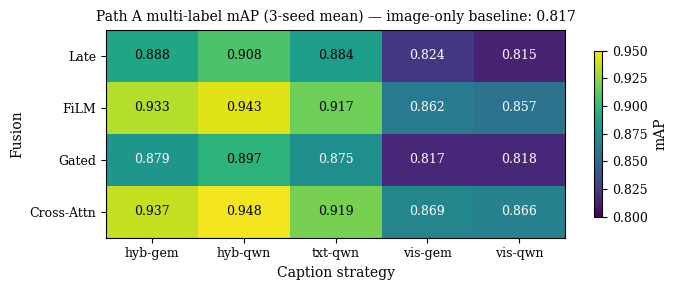

Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/figures/fig1_fusion_heatmap.png


In [56]:
# 2 — Figure 1: fusion × caption mAP heatmap (Path A)
fusion_order = ["late", "film", "gated", "cross_attn"]
fusion_label = {"late": "Late", "film": "FiLM", "gated": "Gated", "cross_attn": "Cross-Attn"}

H = np.zeros((len(fusion_order), len(CAPTION_COLS)))
for i, f in enumerate(fusion_order):
    for j, c in enumerate(CAPTION_COLS):
        H[i, j] = fusion_variants[f"{f}__{c}"]["mAP_mean"]

fig, ax = plt.subplots(figsize=(7.0, 3.0))
im = ax.imshow(H, cmap="viridis", aspect="auto", vmin=0.80, vmax=0.95)

ax.set_xticks(range(len(CAPTION_COLS)))
ax.set_xticklabels([CAPTION_SHORT[c] for c in CAPTION_COLS], rotation=0)
ax.set_yticks(range(len(fusion_order)))
ax.set_yticklabels([fusion_label[f] for f in fusion_order])
ax.set_xlabel("Caption strategy")
ax.set_ylabel("Fusion")

# Annotate each cell with the mAP value
for i in range(len(fusion_order)):
    for j in range(len(CAPTION_COLS)):
        v = H[i, j]
        color = "white" if v < 0.88 else "black"
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", color=color, fontsize=9)

# Image-only baseline as reference annotation
img_baseline = pathA["image_only"]["mAP_mean"]
ax.set_title(f"Path A multi-label mAP (3-seed mean) — image-only baseline: {img_baseline:.3f}",
             fontsize=10)
fig.colorbar(im, ax=ax, label="mAP", shrink=0.8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_fusion_heatmap.png")
plt.show()
print(f"Saved: {FIG_DIR/'fig1_fusion_heatmap.png'}")


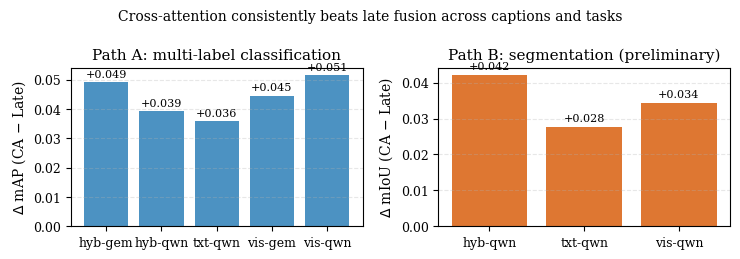

Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/figures/fig2_ca_vs_late_delta.png


In [57]:
# 3 — Figure 2: CA vs Late Δ (Path A mAP + Path B mIoU)
# Path A: 5 captions, Δ in mAP
pathA_deltas = []
pathA_late_stds = []
pathA_ca_stds = []
for cap in CAPTION_COLS:
    L = pathA[f"late__{cap}"]
    C = pathA[f"cross_attn__{cap}"]
    pathA_deltas.append(C["mAP_mean"] - L["mAP_mean"])
    pathA_late_stds.append(L["mAP_std"])
    pathA_ca_stds.append(C["mAP_std"])

# Path B: 3 captions (subset that we ran)
SEG_CAPTIONS = ["hybrid_qwen3-vl-8b", "text_qwen3-4b", "vision_qwen3-vl-8b"]
pathB_deltas = []
for cap in SEG_CAPTIONS:
    L = pathB[f"seg_late__{cap}"]
    C = pathB[f"seg_cross_attn__{cap}"]
    pathB_deltas.append(C["mIoU_mean"] - L["mIoU_mean"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 2.6), sharey=False)

x1 = np.arange(len(CAPTION_COLS))
ax1.bar(x1, pathA_deltas, color="#2c7fb8", alpha=0.85)
ax1.axhline(0, color="black", linewidth=0.6)
ax1.set_xticks(x1)
ax1.set_xticklabels([CAPTION_SHORT[c] for c in CAPTION_COLS], rotation=0)
ax1.set_ylabel(r"$\Delta$ mAP (CA $-$ Late)")
ax1.set_title("Path A: multi-label classification")
ax1.grid(axis="y", linestyle="--", alpha=0.3)
for xi, d in zip(x1, pathA_deltas):
    ax1.text(xi, d + 0.001, f"+{d:.3f}", ha="center", va="bottom", fontsize=8)

x2 = np.arange(len(SEG_CAPTIONS))
ax2.bar(x2, pathB_deltas, color="#d95f0e", alpha=0.85)
ax2.axhline(0, color="black", linewidth=0.6)
ax2.set_xticks(x2)
ax2.set_xticklabels([CAPTION_SHORT[c] for c in SEG_CAPTIONS], rotation=0)
ax2.set_ylabel(r"$\Delta$ mIoU (CA $-$ Late)")
ax2.set_title("Path B: segmentation (preliminary)")
ax2.grid(axis="y", linestyle="--", alpha=0.3)
for xi, d in zip(x2, pathB_deltas):
    ax2.text(xi, d + 0.001, f"+{d:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Cross-attention consistently beats late fusion across captions and tasks",
             fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_ca_vs_late_delta.png")
plt.show()
print(f"Saved: {FIG_DIR/'fig2_ca_vs_late_delta.png'}")


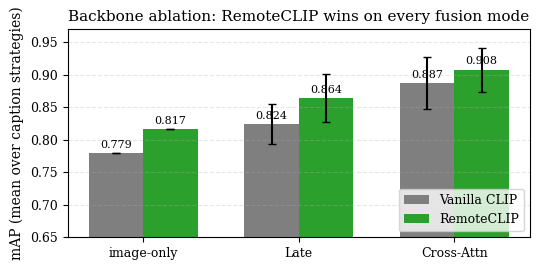

Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/figures/fig3_backbone_compare.png


In [58]:
# 4 — Figure 3: Vanilla CLIP vs RemoteCLIP (per fusion mode)

bb_v = backbone["vanilla"]
bb_r = backbone["remoteclip"]

fusion_groups = {
    "image-only": ["image_only"],
    "Late":       [f"late__{c}" for c in CAPTION_COLS],
    "Cross-Attn": [f"cross_attn__{c}" for c in CAPTION_COLS],
}

# Compute means and stds per group
group_names, vanilla_means, vanilla_stds, rc_means, rc_stds = [], [], [], [], []
for gname, keys in fusion_groups.items():
    v_means = [bb_v[k]["mAP_mean"] for k in keys]
    r_means = [bb_r[k]["mAP_mean"] for k in keys]
    group_names.append(gname)
    vanilla_means.append(float(np.mean(v_means)))
    vanilla_stds.append(float(np.std(v_means)))
    rc_means.append(float(np.mean(r_means)))
    rc_stds.append(float(np.std(r_means)))

x = np.arange(len(group_names))
w = 0.35
fig, ax = plt.subplots(figsize=(5.5, 2.8))
b1 = ax.bar(x - w/2, vanilla_means, w, yerr=vanilla_stds,
            label="Vanilla CLIP", color="#7f7f7f", capsize=3)
b2 = ax.bar(x + w/2, rc_means, w, yerr=rc_stds,
            label="RemoteCLIP", color="#2ca02c", capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(group_names)
ax.set_ylabel("mAP (mean over caption strategies)")
ax.set_ylim(0.65, 0.97)
ax.set_title("Backbone ablation: RemoteCLIP wins on every fusion mode")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")
for bb in (b1, b2):
    for rect in bb:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.005, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_backbone_compare.png")
plt.show()
print(f"Saved: {FIG_DIR/'fig3_backbone_compare.png'}")



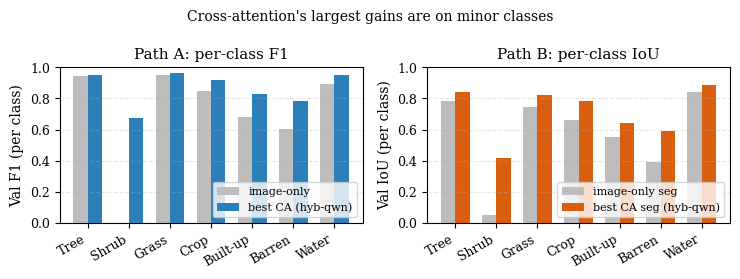

Saved: /content/drive/MyDrive/Colab Notebooks/DI725/phase2_features/figures/fig4_perclass_minor.png


In [59]:
#5 — Figure 4: Per-class minor-class gains (Path A F1 + Path B IoU)
# Best CA condition per task
best_ca_pathA = "cross_attn__hybrid_qwen3-vl-8b"
best_ca_pathB = "seg_cross_attn__hybrid_qwen3-vl-8b"

img_pathA = pathA["image_only"]["f1_per_class_mean"]
ca_pathA  = pathA[best_ca_pathA]["f1_per_class_mean"]

img_pathB = pathB["seg_image_only"]["iou_per_class_mean"]
ca_pathB  = pathB[best_ca_pathB]["iou_per_class_mean"]

x = np.arange(len(CLASSES))
w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 2.8), sharey=False)

# Path A F1
ax1.bar(x - w/2, img_pathA, w, label="image-only", color="#bdbdbd")
ax1.bar(x + w/2, ca_pathA,  w, label="best CA (hyb-qwn)", color="#2c7fb8")
ax1.set_xticks(x); ax1.set_xticklabels(CLASSES, rotation=30, ha="right")
ax1.set_ylabel("Val F1 (per class)")
ax1.set_title("Path A: per-class F1")
ax1.set_ylim(0, 1.0)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.legend(loc="lower right", fontsize=8)

# Path B IoU
ax2.bar(x - w/2, img_pathB, w, label="image-only seg", color="#bdbdbd")
ax2.bar(x + w/2, ca_pathB,  w, label="best CA seg (hyb-qwn)", color="#d95f0e")
ax2.set_xticks(x); ax2.set_xticklabels(CLASSES, rotation=30, ha="right")
ax2.set_ylabel("Val IoU (per class)")
ax2.set_title("Path B: per-class IoU")
ax2.set_ylim(0, 1.0)
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.legend(loc="lower right", fontsize=8)

fig.suptitle("Cross-attention's largest gains are on minor classes", fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_perclass_minor.png")
plt.show()
print(f"Saved: {FIG_DIR/'fig4_perclass_minor.png'}")



In [60]:
# 6 — List all figures + report-ready summary printout
print("\n=== Generated figures (Drive) ===")
for f in sorted(FIG_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")
print(f"\nAlso available from 05_pathB_segmentation:")
print(f"  fig_seg_qualitative.png")
print(f"  fig_seg_attention_overlay.png")

print("\n=== Headline numbers for the report ===")
print(f"Path A:")
print(f"  image-only baseline: mAP {pathA['image_only']['mAP_mean']:.3f} ± {pathA['image_only']['mAP_std']:.3f}")
print(f"  best CA (hybrid_qwen): mAP {pathA[best_ca_pathA]['mAP_mean']:.3f} ± {pathA[best_ca_pathA]['mAP_std']:.3f}")
print(f"  fusion gain: +{pathA[best_ca_pathA]['mAP_mean'] - pathA['image_only']['mAP_mean']:.3f} mAP")
print(f"\nPath B:")
print(f"  image-only seg: mIoU {pathB['seg_image_only']['mIoU_mean']:.3f} ± {pathB['seg_image_only']['mIoU_std']:.3f}")
print(f"  best CA seg (hybrid_qwen): mIoU {pathB[best_ca_pathB]['mIoU_mean']:.3f} ± {pathB[best_ca_pathB]['mIoU_std']:.3f}")
print(f"  fusion gain: +{pathB[best_ca_pathB]['mIoU_mean'] - pathB['seg_image_only']['mIoU_mean']:.3f} mIoU")

print(f"\nBackbone ablation:")
v_means = [bb_v[k]['mAP_mean'] for k in bb_v]
r_means = [bb_r[k]['mAP_mean'] for k in bb_r]
deltas = [r - v for v, r in zip(v_means, r_means)]
print(f"  RemoteCLIP > Vanilla CLIP on {sum(1 for d in deltas if d > 0)}/{len(deltas)} conditions")
print(f"  avg Δ mAP: +{np.mean(deltas):.3f}  (best +{max(deltas):.3f}, worst +{min(deltas):.3f})")

print(f"\nFusion family means (mAP):")
for fusion in ["late", "film", "gated", "cross_attn"]:
    means = [fusion_variants[f"{fusion}__{c}"]["mAP_mean"] for c in CAPTION_COLS]
    print(f"  {fusion:12s} {np.mean(means):.3f}  (range {min(means):.3f}–{max(means):.3f})")



=== Generated figures (Drive) ===
  fig1_fusion_heatmap.png  (162.4 KB)
  fig2_ca_vs_late_delta.png  (135.8 KB)
  fig3_backbone_compare.png  (113.0 KB)
  fig4_perclass_minor.png  (140.0 KB)

Also available from 05_pathB_segmentation:
  fig_seg_qualitative.png
  fig_seg_attention_overlay.png

=== Headline numbers for the report ===
Path A:
  image-only baseline: mAP 0.817 ± 0.001
  best CA (hybrid_qwen): mAP 0.948 ± 0.003
  fusion gain: +0.131 mAP

Path B:
  image-only seg: mIoU 0.574 ± 0.003
  best CA seg (hybrid_qwen): mIoU 0.711 ± 0.003
  fusion gain: +0.137 mIoU

Backbone ablation:
  RemoteCLIP > Vanilla CLIP on 11/11 conditions
  avg Δ mAP: +0.031  (best +0.050, worst +0.014)

Fusion family means (mAP):
  late         0.864  (range 0.815–0.908)
  film         0.903  (range 0.857–0.943)
  gated        0.857  (range 0.817–0.897)
  cross_attn   0.908  (range 0.866–0.948)


## Generated figures

### fig1_fusion_heatmap.png

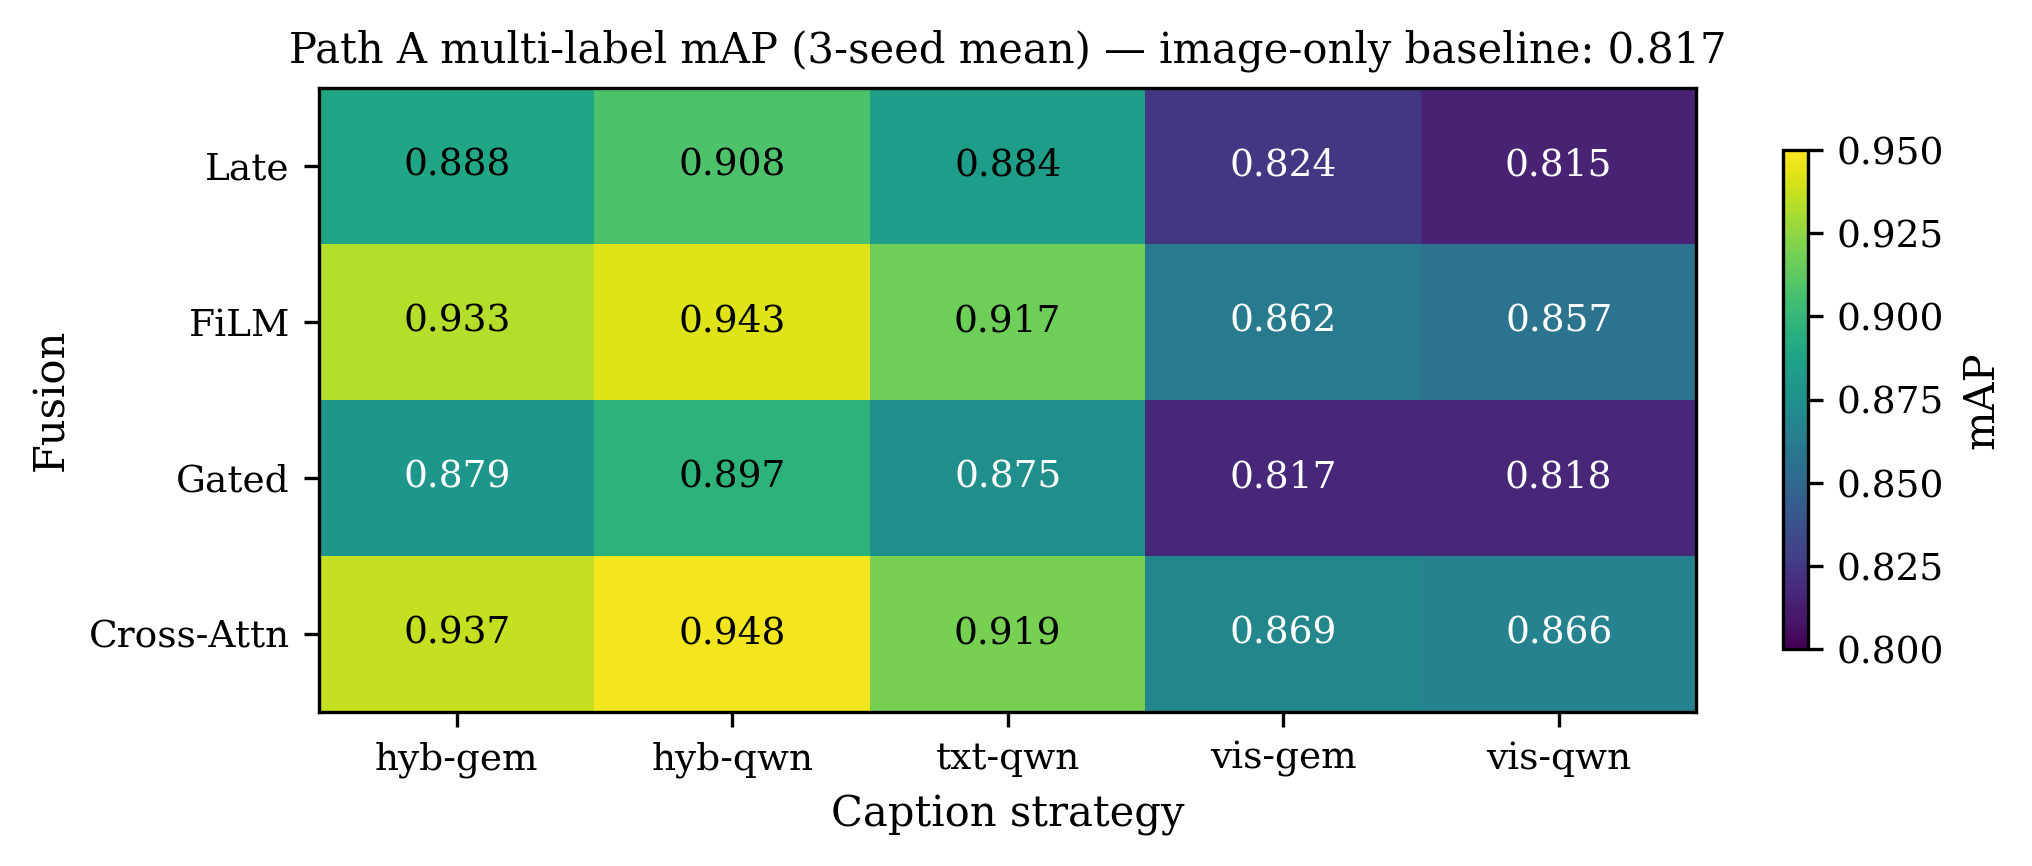

### fig2_ca_vs_late_delta.png

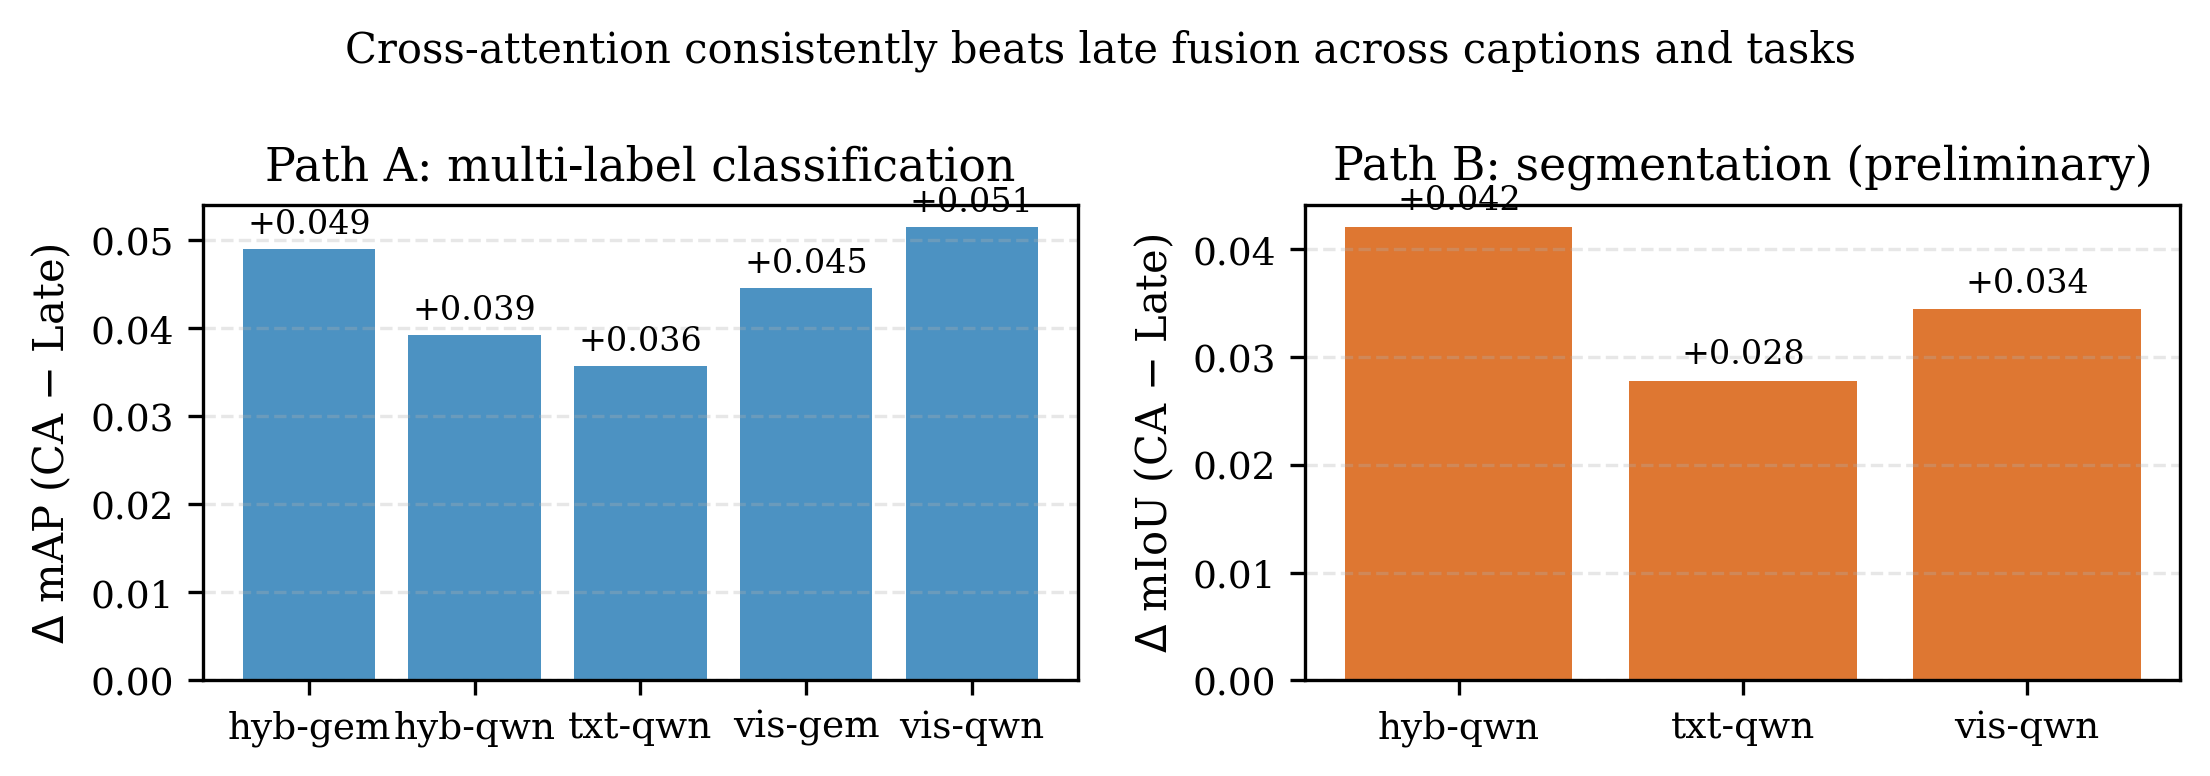

### fig3_backbone_compare.png

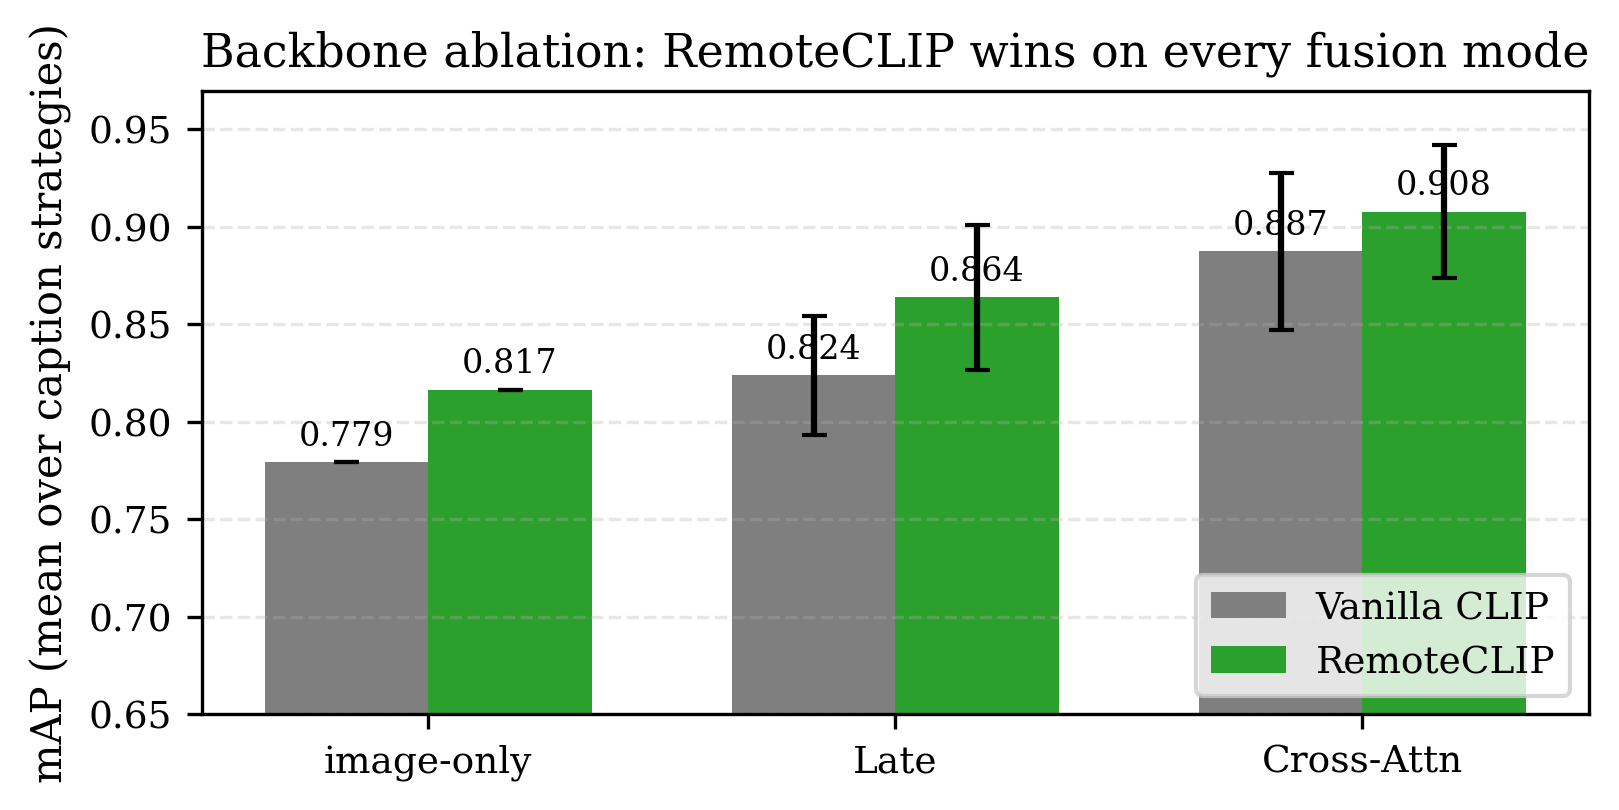

### fig4_perclass_minor.png

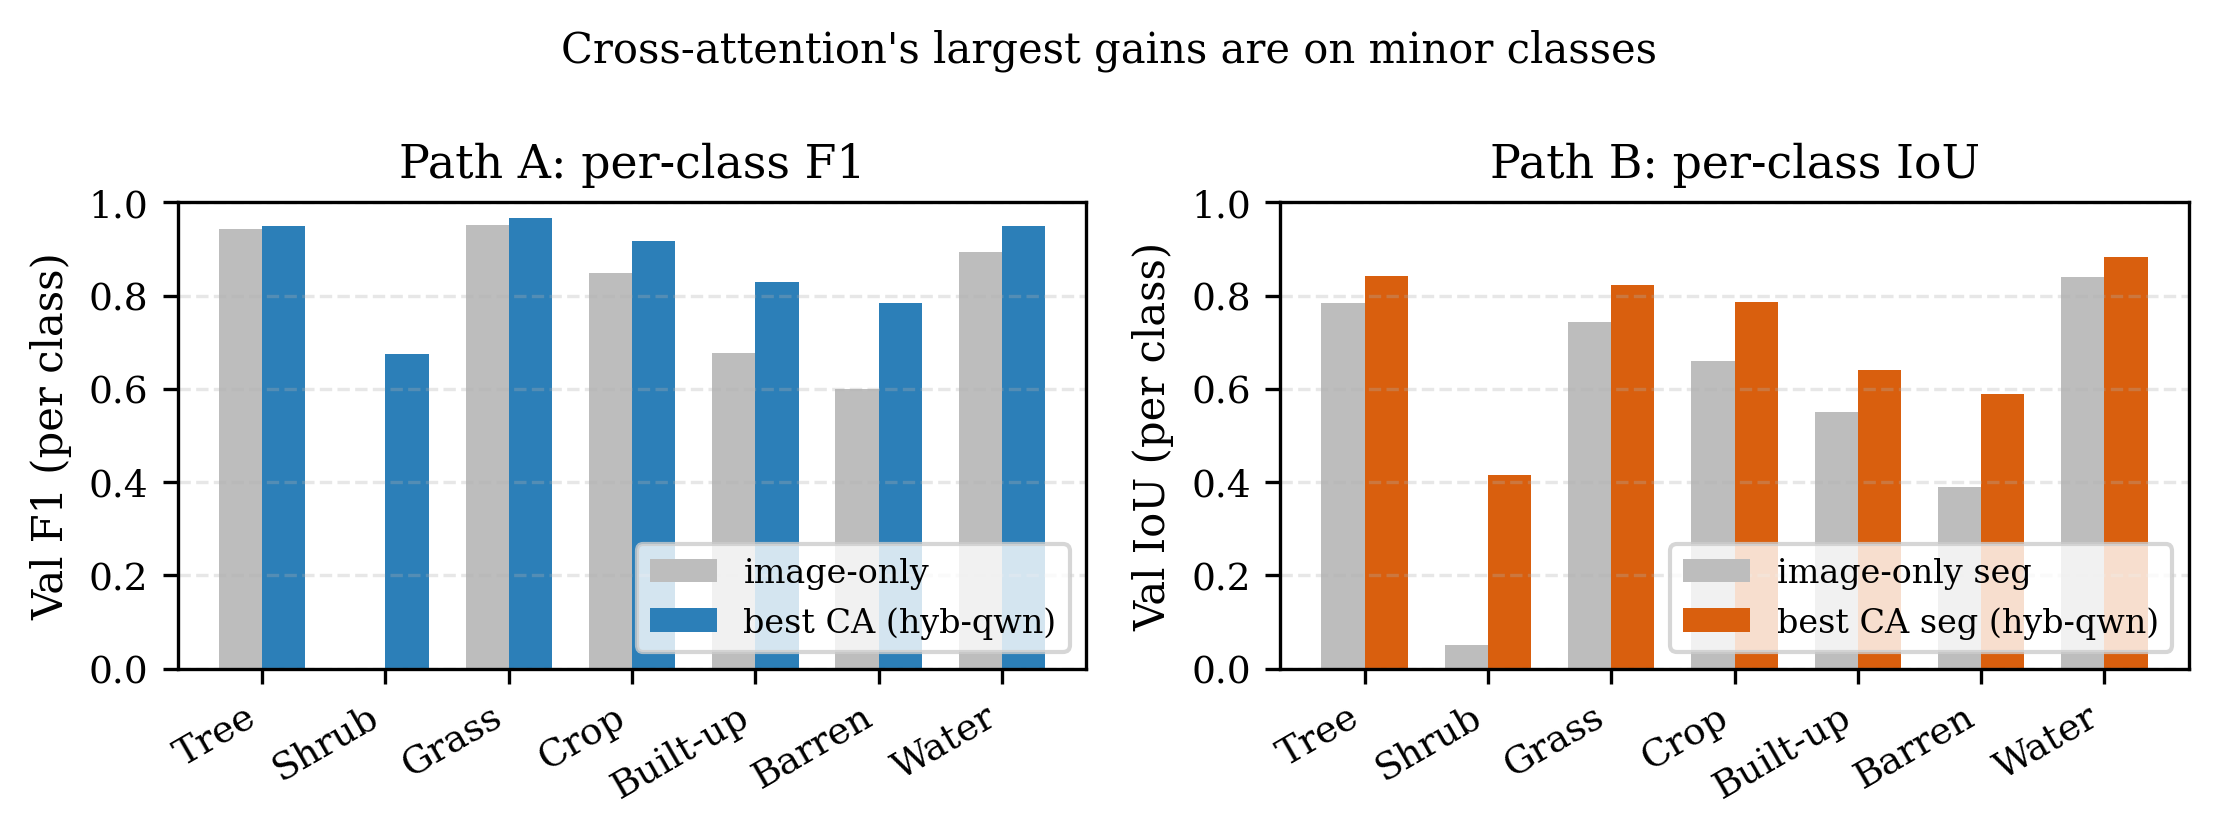

## Segmentation figures (from 05_pathB_segmentation)

### fig_seg_qualitative.png

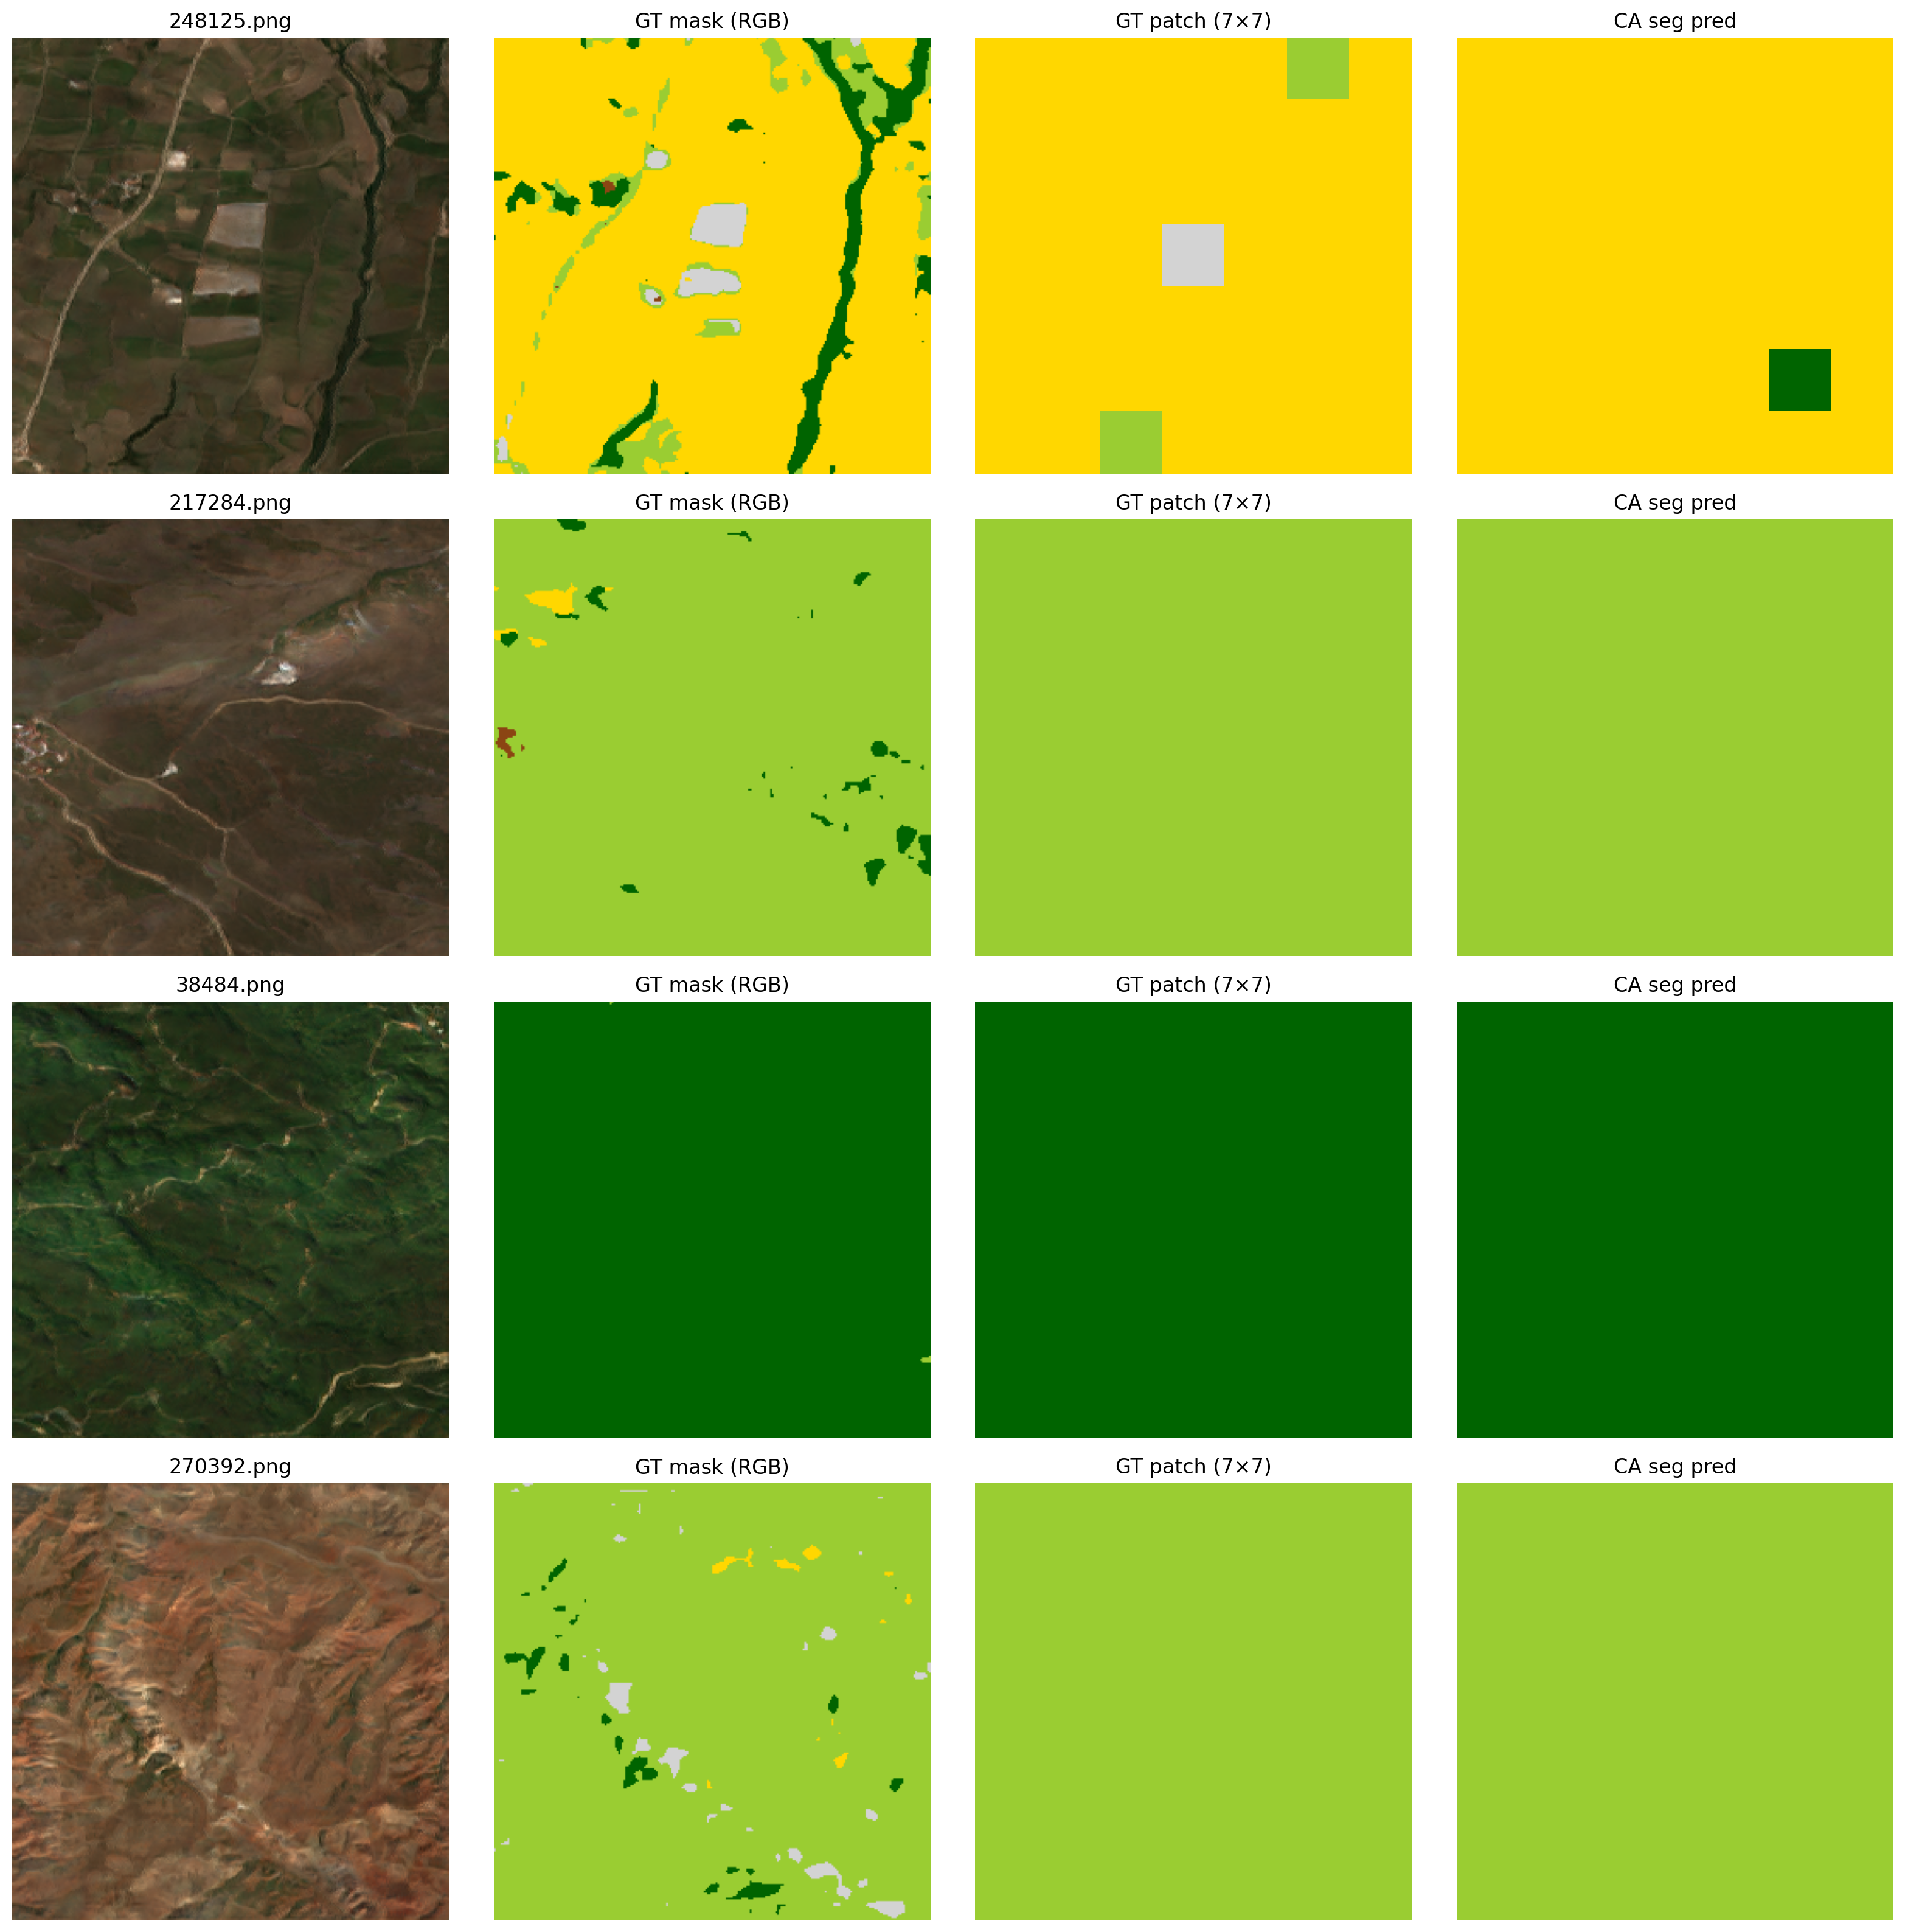

### fig_seg_attention_overlay.png

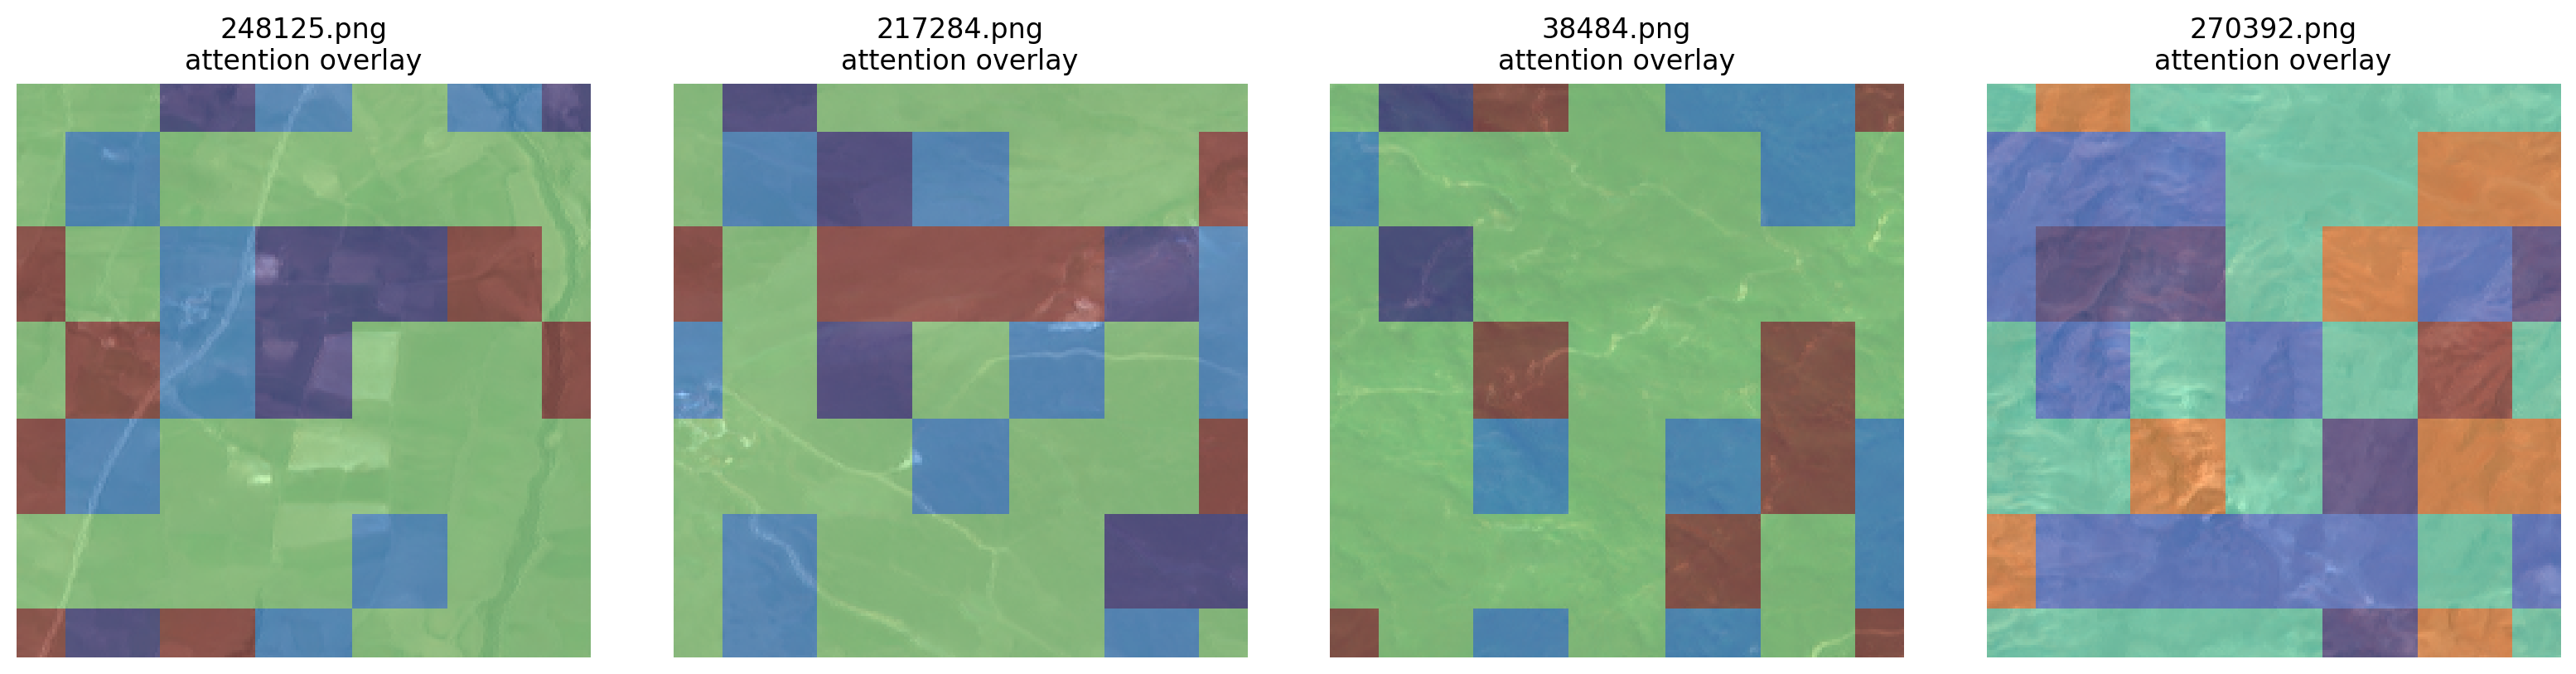

In [61]:
# 7 — Re-display saved figures inline (in case earlier cells didn't render)
# Uses IPython.display.Image so the saved PNGs show even if matplotlib state was cleared.

from IPython.display import Image, display, Markdown

display(Markdown("## Generated figures"))
for fname in ["fig1_fusion_heatmap.png", "fig2_ca_vs_late_delta.png",
              "fig3_backbone_compare.png", "fig4_perclass_minor.png"]:
    p = FIG_DIR / fname
    if p.exists():
        display(Markdown(f"### {fname}"))
        display(Image(filename=str(p)))

display(Markdown("## Segmentation figures (from 05_pathB_segmentation)"))
for fname in ["fig_seg_qualitative.png", "fig_seg_attention_overlay.png"]:
    p = FEAT_DIR / fname
    if p.exists():
        display(Markdown(f"### {fname}"))
        display(Image(filename=str(p)))

In [62]:
#  8 — Bundle figures + result JSONs into a zip and trigger browser download

import zipfile
from google.colab import files

zip_path = "/content/phase2_outputs.zip"

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    # Report figures
    for f in (FEAT_DIR / "figures").iterdir():
        zf.write(f, f"figures/{f.name}")
    # Segmentation figures (saved at top level of FEAT_DIR by 05_pathB)
    for fname in ["fig_seg_qualitative.png", "fig_seg_attention_overlay.png"]:
        p = FEAT_DIR / fname
        if p.exists():
            zf.write(p, f"figures/{fname}")
    # All results JSONs
    for fname in ["pathA_results.json", "pathA_results_multi_seed.json",
                  "pathA_backbone_ablation.json", "pathA_fusion_variants.json",
                  "pathB_seg_results.json"]:
        p = FEAT_DIR / fname
        if p.exists():
            zf.write(p, f"results/{fname}")

# Print contents of the zip
print(f"Zip: {zip_path}  ({Path(zip_path).stat().st_size / 1024:.1f} KB)")
with zipfile.ZipFile(zip_path) as zf:
    for n in zf.namelist():
        info = zf.getinfo(n)
        print(f"  {n}  ({info.file_size / 1024:.1f} KB)")

print("\nTriggering browser download (check your Downloads folder)...")
files.download(zip_path)


Zip: /content/phase2_outputs.zip  (3301.3 KB)
  figures/fig1_fusion_heatmap.png  (162.4 KB)
  figures/fig2_ca_vs_late_delta.png  (135.8 KB)
  figures/fig3_backbone_compare.png  (113.0 KB)
  figures/fig4_perclass_minor.png  (140.0 KB)
  figures/fig_seg_qualitative.png  (2485.3 KB)
  figures/fig_seg_attention_overlay.png  (413.6 KB)
  results/pathA_results.json  (3.6 KB)
  results/pathA_results_multi_seed.json  (19.5 KB)
  results/pathA_backbone_ablation.json  (15.7 KB)
  results/pathA_fusion_variants.json  (13.9 KB)
  results/pathB_seg_results.json  (4.0 KB)

Triggering browser download (check your Downloads folder)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>